### `📤 Import Libraries`.

In [217]:
import os
import io
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as tkr
import psycopg2
import xlsxwriter
import scipy.stats
import dataframe_image as dfi
import time
import tarfile # Read and write tar archives, including those using gzip, bz2 and lzma compression.
import zipfile # Read or write (.zip) files, or the higher-level functions in shutil
import urllib.request # Open and fetch data from URLs
import warnings
warnings.filterwarnings('ignore')

#==#

from io import BytesIO
from numpy import mean, absolute
from numpy import median, absolute
from sqlalchemy import create_engine
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter, FuncFormatter, PercentFormatter, MultipleLocator, AutoMinorLocator
from matplotlib import font_manager
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.cbook import boxplot_stats
from pandas.io.formats.style import Styler
from pandas.io.formats.excel import ExcelFormatter
from openpyxl import Workbook
from scipy import stats
from scipy.stats import norm # Normalisation of data
from scipy.stats import trim_mean
from statistics import variance
from statistics import stdev
from sklearn import metrics
from sklearn.linear_model import LinearRegression # Statistical method for predicting an outcome based on one or more influencing factors
from sklearn.linear_model import LogisticRegression # Statistical method for predicting binary classes
from sklearn.model_selection import train_test_split, GridSearchCV # Split arrays or matrices into random train and test subsets, Test multiple scenarios to get the best performing performace for the model
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler # Standardise data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer # Apply transformers to specific columns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Visualise complex high-dimensional data in a lower-dimensional space
from sklearn.cluster import KMeans # KMeans method from sklearn to build the K-Means model
from yellowbrick.cluster import KElbowVisualizer # KElbowVisualizer to visualise K-Means model performance
from fpdf import FPDF
from PIL import Image
from IPython.display import HTML, display
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from datetime import timedelta # Represent the difference between two datetime objects.
from pathlib import Path

#==#

# Time series and forecasting libraries
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose # Use for seasonal sales data
import statsmodels.api as sm

# For advanced forecasting
from prophet import Prophet  # Requires `pip install prophet`

# Model evaluation
from sklearn.metrics import confusion_matrix # Evaluate the accuracy of a classification.
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

#==#

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

#==#

# Apriori algorithm and association rule mining libraries
import networkx as nx # Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.
from mlxtend.frequent_patterns import apriori, association_rules # Get frequent itemsets from a one-hot DataFrame, Generates a DataFrame of association rules including the metrics 'score', 'confidence', and 'lift'
from mlxtend.preprocessing import TransactionEncoder # Encoder class for transaction data in Python lists

#==#

from lifetimes import BetaGeoFitter, GammaGammaFitter # BG/NBD + Gamma-Gamma model for Predicting Customer Lifetime Value (CLTV)
from lifetimes.utils import summary_data_from_transaction_data

#==#

# pd.options.display.max_columns = 100
# pd.set_option('display.max_columns', 100)

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Prevent line wrapping of wide columns (for cleaner display)
pd.set_option('display.expand_frame_repr', False)

# Display nicely
pd.set_option('display.max_colwidth', None)

#==#

%matplotlib inline

### `📥 Load Dataframe`.

In [218]:
# Define path to california housing market data analysis file
file_path = os.path.expanduser("~/Python-Documents/os/CSV Files/California_Housing_Market_Data_Analysis_modified_3.csv")

# Read and copy data
read_csv = pd.read_csv(file_path)
final = read_csv.copy()

# Display first 2 rows
final.head(2)

#==#

# # Load the dataset
# file_path = r"\Users\tailb\Python-Documents\os\CSV Files\California_Housing_Market_Data_Analysis_modified_3.csv"

# # Read and copy data
# read_csv = pd.read_csv(file_path)
# final = read_csv.copy()

# # Display first 2 rows
# final.head(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity,MHV_cluster,MHV_cluster_name,price_cluster,price_cluster_name,wealth_cluster,wealth_cluster_name,geo_cluster,geo_cluster_name,market_segment_cluster,market_segment_cluster_name,Risk,Return,Best Strategy,Annotated Summary
0,-122.23,37.88,322.0,126.0,880.0,129.0,2.555556,6.984127,2.732919,3257.686957,0.146591,41.0,8325.2,452600.0,NEAR BAY,1,🏆 Premium,1,🏆 Affluent Districts,1,🏰 Luxury Zones,0,Northern California,2,🏡 Inland NorCal Budget,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold
1,-122.22,37.86,2401.0,1138.0,7099.0,1106.0,2.109842,6.238137,2.956685,3934.607747,0.155797,21.0,8301.4,358500.0,NEAR BAY,1,🏆 Premium,1,🏆 Affluent Districts,1,🏰 Luxury Zones,0,Northern California,2,🏡 Inland NorCal Budget,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold


### `🤖📌 Machine Learning Project Objectives`.

**`🧭 What are the objectives of the machine learning project?`**:
- --
  - **1 `📌 To predict median house values based on features like income, room ratios, housing age and location`**.

  - **2 `📌 To identify and analyse the distribution of housing values across key California locations`**.
     
  - **3 `📌 To segment California housing markets into meaningful clusters using KMeans clustering`**.
     
  - **4 `📌 To determine the best housing investment strategy (PB&H, F&F or AFD) per geographic location`**.
  
  - **4 `📌 To visualise geographic housing patterns across California using geospatial mapping`**.
     
  - **5 `📌 To explore the relationship between ocean proximity, median income and median house value`**.
     
  - **6 `📌 To provide data-driven prescriptive recommendations for housing strategy selection by location`**.

- --

**`🌍 Real World Applications`**:
- --
- **1`📌 Visualise Spatial Distributions: Map key housing features (MHV, income, income per capita, ocean proximity, housing strategy, locations) to reveal geographic patterns and hotspots`**.

- **2`📌 Conduct Multivariate EDA: Profile interrelationships between socioeconomic variables and spatial factors to uncover correlations driving house prices`**.

- **3`📌 Identify Regional Insights: Highlight clusters/segments (e.g., high-value coastal vs. inland areas) for targeted analysis and strategy`**.

- **4`📌 Support Price Prediction: Provide foundational geospatial context to enhance model interpretability, feature engineering, and real-world deployment (e.g., investor targeting, policy planning)`**.

- **5`📌 Enable Stakeholder Decisions: Deliver actionable visuals for buyers, investors, banks, and policymakers to assess market risks/opportunities spatially`**.

### `🌍✨ Geospatial KMeans Clustering: Multivariate Analysis`.

##### `📥 Load Dataframe`.

In [219]:
# Define path to california housing market data analysis file
file_path = os.path.expanduser("~/Python-Documents/os/CSV Files/California_Housing_Market_Data_Analysis_modified_3.csv")

# Read and copy data
read_csv = pd.read_csv(file_path)
final = read_csv.copy()

# Display first 2 rows
final.head(2)

#==#

# # Load the dataset
# file_path = r"\Users\tailb\Python-Documents\os\CSV Files\California_Housing_Market_Data_Analysis_modified_3.csv"

# # Read and copy data
# read_csv = pd.read_csv(file_path)
# final = read_csv.copy()

# # Display first 2 rows
# final.head(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity,MHV_cluster,MHV_cluster_name,price_cluster,price_cluster_name,wealth_cluster,wealth_cluster_name,geo_cluster,geo_cluster_name,market_segment_cluster,market_segment_cluster_name,Risk,Return,Best Strategy,Annotated Summary
0,-122.23,37.88,322.0,126.0,880.0,129.0,2.555556,6.984127,2.732919,3257.686957,0.146591,41.0,8325.2,452600.0,NEAR BAY,1,🏆 Premium,1,🏆 Affluent Districts,1,🏰 Luxury Zones,0,Northern California,2,🏡 Inland NorCal Budget,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold
1,-122.22,37.86,2401.0,1138.0,7099.0,1106.0,2.109842,6.238137,2.956685,3934.607747,0.155797,21.0,8301.4,358500.0,NEAR BAY,1,🏆 Premium,1,🏆 Affluent Districts,1,🏰 Luxury Zones,0,Northern California,2,🏡 Inland NorCal Budget,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold


In [220]:
# final.plot(kind="scatter", x="longitude", y="latitude", grid=True,alpha=0.2)
# plt.show()

#==#

# final.plot(kind="scatter", x="longitude", y="latitude", 
# grid=True, s=housing["population"] / 100, label="population",
# c="median_house_value", cmap="jet", colorbar=True,
# legend=True, sharex=False, figsize=(10, 7))
# plt.show()

##### `👁️⃤  Correlation Matix: Correlation Analysis Of Key Metrics`.

In [221]:
corr_matrix = final.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False) # Sorted from highest to lowest.
# corr_matrix # Unsorted.

median_house_value        1.000000
income_per_person         0.679062
median_income             0.634155
MHV_cluster               0.558860
wealth_cluster            0.558132
price_cluster             0.558132
market_segment_cluster    0.424486
rooms_per_person          0.142806
total_rooms               0.131865
rooms_per_house           0.104243
households                0.078362
geo_cluster               0.071319
total_bedrooms            0.058778
housing_median_age        0.027203
population                0.005782
longitude                -0.037052
latitude                 -0.137370
people_per_house         -0.145168
bedrooms_ratio           -0.216159
Name: median_house_value, dtype: float64

**`📊 Key Insights`**:
- --
- **`Strong Positive Correlations`**
  - **`income_per_person` `(0.6790)` is by far the `strongest predictor` of house value followed by `median_income` `(0.6341)` — `higher income areas` tend to have `significantly more expensive homes`. This is your most important feature**.
- --
- **`Weak Positive Correlations`**
  - **`rooms_per_person` `(0.1428)` - `More rooms per person` suggests `less overcrowding`, marginally linked to `higher value`**.
  - **`total_rooms` `(0.1318)` — `More rooms` suggests `marginally higher value`**.
  - **`rooms_per_house` `(0.1042)`, `households` `(0.0783)`, `geo_cluster` `(0.0713)`, `total_bedrooms` `(0.0584)` — `Negligible positive relationships`**.
  - **`housing_median_age` `(0.0272)`, `population` `(0.0057)`— `Negligible positive relationships`**.
- --
- **`Negative Correlations`**
  - **`longitude` `(-0.0370)` - `Moving east` correlates with `slightly lower prices`**.
  - **`latitude` `(-0.1373)` — `Moving north` correlates with `lower prices` (likely reflects California geography)**.
  - **`people_per_house` `(-0.1451)` — `More people per house` suggests `overcrowding`, weakly linked to `lower values`**.
  - **`bedrooms_ratio` `(-0.2162)` — `Higher bedroom ratio` correlates with `lower value`**.
  - **`market_segment_cluster` `(-0.4635)` — `TBC`**.
  - **`longitude`, `population`, `bedroom_ratio`, `market_segment_cluster` — `Very weak negative relationships`**.
  - **(`more bedrooms relative to rooms` = `smaller, cheaper properties`)**.
---
- **`🎯 Conclusion`**
  - **`income_per_person` dominates — `Our anchor feature`**.
  - **`population`, `people_per_house` and `longitude` have `correlations close to 0`, meaning they have `negligible negative relationships` with house prices**.
  - **`people_per_house` `(-0.1451)` is the `3rd strongest negative predictor` in the dataset**.
  - **`bedrooms_ratio` `(-0.2162)` is the `2nd strongest negative predictor` in the dataset**. 
  - **`market_segment_cluster` `(-0.4635)` is the `1st strongest negative predictor` in the dataset**. 
  - **Geographic features `(latitude/longitude)` show `weak linear correlations` individually. However, `combined together` they represent `location` which is a `powerful predictor` of house prices**.

##### `🗃️ Feature Selection & Train/Test Split For Cluster-Based Model`.

In [222]:
# Feature selection & train/test split for cluster-based model

# Import Libraries
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy and load dataset
housing = final.copy()

# Features: use lat/lon for clustering + other features for prediction
X = housing[[
    'income_per_person',    # Engineered — strongest correlator (0.75) — affordability metric
    'median_income',        # Strong predictor — highest individual correlation (0.69)
    # 'MHV_cluster',          # ❌ Leakage — built using median_house_value (target variable)
    # 'wealth_cluster',       # ❌ Leakage — built using median_house_value (target variable)
    # 'price_cluster',        # ❌ Leakage — built using median_house_value (target variable)
    'rooms_per_person',     # Engineered — captures overcrowding in cheaper areas
    'rooms_per_house',      # Engineered — captures property size per household
    'geo_cluster',          # Derived from lat/lon clustering
    'housing_median_age',   # Age of property — impacts valuation
    'latitude',             # Geographic pattern — north/south price variation
    'longitude',            # Geographic pattern — east/west price variation
    'people_per_house',     # Engineered — captures
    'bedrooms_ratio',       # Engineered — bedroom proportion signals property type
    # 'total_rooms',          # Already "encoded" inside bedrooms_ratio
    # 'total_bedrooms',       # Already "encoded" inside bedrooms_ratio
    # 'housing_median_age',   # Drop near-zero correlators
    # 'population',           # Already "encoded" inside people_per_house / # Drop near-zero correlators.
]]

# Dropping
# 'total_bedrooms', 'households' & population — multicollinearity risk with other features

# Create Y with our Target variable
y = housing['median_house_value']

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42)

##### `👾 Model Evaluation: R² Score Comparison`.

In [223]:
# Model Evaluation: R² Score Comparison
# - With Clustering (ClusterSimilarity + LinearRegression)
# - Without Clustering (StandardScaler + LinearRegression)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, 
                              random_state=self.random_state,
                              n_init=10)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        from sklearn.metrics.pairwise import rbf_kernel
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"cluster_{i}_similarity" for i in range(self.n_clusters)]

#==#

from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector

# Use ClusterSimilarity on lat/lon columns
cluster_similarity = ClusterSimilarity(n_clusters=10, 
                                        gamma=1.0, 
                                        random_state=42)

# Extract lat/lon
location_pipeline = make_pipeline(
    cluster_similarity
)

# Full preprocessor
preprocessor = ColumnTransformer([
    ("cluster", cluster_similarity, ["latitude", "longitude"]),
    ("scaler", StandardScaler(), [
        'income_per_person',    # ✅ Kept
        'median_income',        # ✅ Kept
        'rooms_per_person',     # ✅ Kept
        'rooms_per_house',      # ✅ Kept
        'housing_median_age',   # ✅ Kept
        'people_per_house',     # ✅ Added — was missing from preprocessor
        'bedrooms_ratio',       # ✅ Kept
        # 'population'          # ❌ Removed — not in X
    ]),


])
   
# Full pipeline
pipeline = make_pipeline(
    preprocessor,
    LinearRegression()
)

# Train and evaluate
pipeline.fit(X_train, y_train)
print(f"R² Score with clustering:: {pipeline.score(X_test, y_test):.3f}")

#==#

# WITHOUT clustering
no_cluster_pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)
no_cluster_pipeline.fit(X_train, y_train)
print(f"R² score without clustering: {no_cluster_pipeline.score(X_test, y_test):.3f}")

R² Score with clustering:: 0.632
R² score without clustering: 0.611


##### `⚙️ Set Plot Context And Style`.

In [224]:
# Set plot context and style

# Step 1: Set font dictionaries
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
x_label_font = {'family':'verdana','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

# Step 2: Set styles
context = sns.set_context("notebook") # ('paper', 'notebook', 'talk', 'poster')
# style = sns.axes_style() # ('darkgrid', 'whitegrid', 'dark', 'white', 'ticks')
style = sns.axes_style("ticks",{
    # Figure
    'figure.figsize':(10, 6),'figure.dpi':100,   
    # Grid (grid.axis:'x', 'y', 'both', grid.which: 'major', 'minor', 'both')
    'axes.grid':True, 'grid.linestyle':'-.','grid.linewidth':0.2,'grid.color':'white', 'grid.alpha':0.2,'axes.grid.axis':'both', 'axes.grid.which':'major',
    # Axes Background
    'axes.facecolor':'white','figure.facecolor':'lightblue','axes.alpha':1.0, # lightblue
    # Axes Border (Spines)
    'axes.edgecolor':'cyan', 'axes.linewidth': 1.5, 'axes.spines.top': False,'axes.spines.right':False, 'axes.spines.left':True, 'axes.spines.bottom':True,
    # Axes Labels (x/y label color, x/y label font size)
    'axes.labelcolor':'black', 'axes.labelsize': 'medium', 'axes.labelweight':'normal', 'axes.labelpad':4.0,  
    # Tick Marks
    'xtick.bottom':True,'xtick.top':False, 'xtick.color':'darkgreen', 'xtick.labelcolor':'darkred', 'xtick.labelsize':7,
    'xtick.major.size':6, 'xtick.major.width':2,'xtick.major.pad':4, 'xtick.minor.size':3,'xtick.minor.width':0.5, 'xtick.direction':'out',
    'ytick.left':True, 'ytick.right':False, 'ytick.color':'darkblue', 'ytick.labelcolor':'darkgreen', 'ytick.labelsize':7,
    'ytick.major.size':6,'ytick.major.width':2, 'ytick.major.pad':4,'ytick.minor.size':3, 'ytick.minor.width':0.5,'ytick.direction':'out',
    # Lines (-, --, -., :, solid, dashed, dashdot, dotted)
    'lines.linewidth':1.5, 'lines.markersize':6, 'lines.linestyle':'-',
    # Font (global font family, global font size)
    'font.family': 'consolas', 'font.size':10, 'font.style':'normal', 'font.weight':'normal',
    # Legend(legend border box, legend transparency, legend border color & legend background)
    'legend.frameon':True, 'legend.framealpha':0.8, 'legend.edgecolor':'black', 'legend.facecolor':'white'})        

# Step 3: Set theme
sns.set_theme(context=context, style=style, palette='bright', font='tahoma', font_scale=None, color_codes=True)

##### `🏡 California Housing: Median House Value, Income And Income Per Person Per Geographic Cluster`.

**`Print Dataframe Columns`**

In [225]:
print(final.columns.tolist())

['longitude', 'latitude', 'population', 'households', 'total_rooms', 'total_bedrooms', 'people_per_house', 'rooms_per_house', 'rooms_per_person', 'income_per_person', 'bedrooms_ratio', 'housing_median_age', 'median_income', 'median_house_value', 'ocean_proximity', 'MHV_cluster', 'MHV_cluster_name', 'price_cluster', 'price_cluster_name', 'wealth_cluster', 'wealth_cluster_name', 'geo_cluster', 'geo_cluster_name', 'market_segment_cluster', 'market_segment_cluster_name', 'Risk', 'Return', 'Best Strategy', 'Annotated Summary']


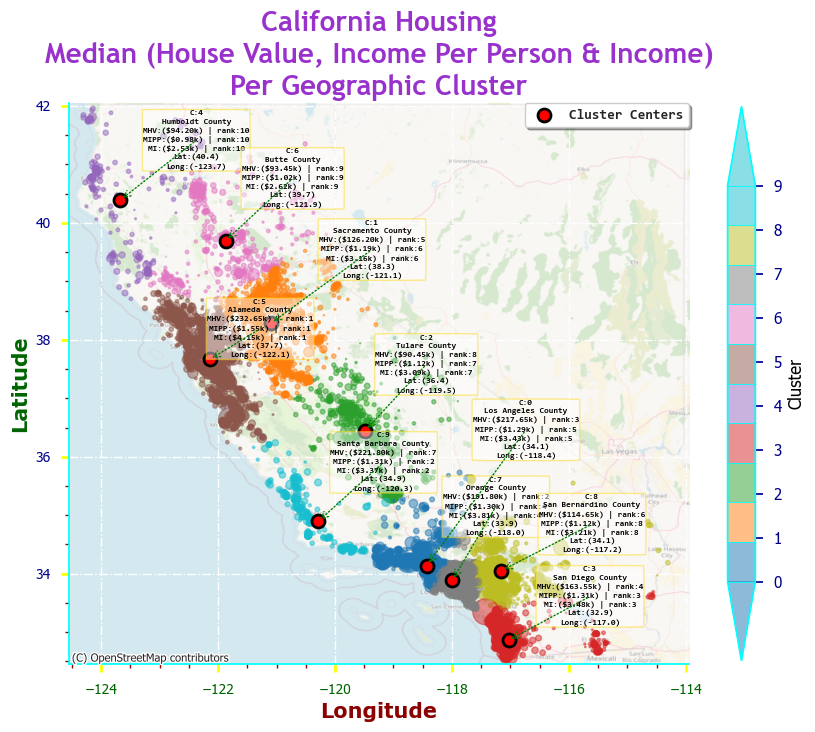

In [226]:
# Geographic cluster visualisation
# - KMeans clustering on lat/lon
# - Median house value & income per cluster
# - OpenStreetMap (via contextily) basemap overlay

#==#

# Fit KMeans on location
kmeans = KMeans(n_clusters=10, random_state=42)
final["Cluster"] = kmeans.fit_predict(final[["latitude", "longitude"]])
median_house_value = final.groupby("Cluster")["median_house_value"].median()
income_per_person = final.groupby("Cluster")["income_per_person"].median()
median_income = final.groupby("Cluster")["median_income"].median()

#==#

# MAP 1 - Median House Value, Median Income and Median Income Per Person Per Geographic Cluster

# Pre-compute median house value sum per Cluster
mhv_cluster_medians = final.groupby("Cluster")["median_house_value"].median()

# Rank across all median house value clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mipp_cluster_medians = final.groupby("Cluster")["income_per_person"].median()

# Rank across all median income per person clusters (highest value = rank 1)
mipp_cluster_ranks = mipp_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mi_cluster_medians = final.groupby("Cluster")["median_income"].median()

# Rank across all ocean_proximity clusters (highest value = rank 1)
mi_cluster_ranks = mi_cluster_medians.rank(ascending=False, method='min').astype(int)

#==#

# MAP 2 - Ocean Proximity and Median House Value Per Geographic Cluster

# Calculate grand totals
grand_total_count = final['ocean_proximity'].value_counts().sum()
grand_total_value = final['median_house_value'].sum()

# Show all ocean proximity, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
ocean_proximity = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{k}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['ocean_proximity'].value_counts().items()])
        + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['ocean_proximity'].value_counts().sum()/grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all mhv clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute total ocean proximity count per Cluster
op_cluster_totals = final.groupby("Cluster")["ocean_proximity"].count()

# Rank across all ocean_proximity clusters (highest value = rank 1)
op_cluster_ranks = op_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# MAP 3 - Housing Strategy and Median House Value Per Geographic Cluster

# Shortened version for cleaner map
strategy_short = {
    'Premium Buy & Hold': 'PB&H',
    'Volume Investment (Fix & Flip)': 'F&F',
    'Affordable Development': 'AFD'
}

# Map shortened names
final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# Calculate grand totals
bs_grand_total_count = final['Best Strategy'].value_counts().sum()
bs_grand_total_value = final['median_house_value'].sum()

# Get all strategies per cluster with shortened names, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
best_strategy = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['Best Strategy'].value_counts().items()])
        + f"\nTOTAL:{x['Best Strategy'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['Best Strategy'].value_counts().sum()/bs_grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/bs_grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
bs_mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all median house value clusters (highest value = rank 1)
bs_mhv_cluster_ranks = bs_mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute best strategy count per Cluster
bs_cluster_totals = final.groupby("Cluster")["Best Strategy Short"].count()

# Rank across all best strategy clusters (highest value = rank 1)
bs_cluster_ranks = bs_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# # MAP 2 - CODE 2
# # Show all ocean proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{[k]}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False)

#==#

# # MAP 2 - CODE 3
# # Show all ocean_proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x['ocean_proximity'].value_counts().items()])
#                          + f"\nCNT:{x['ocean_proximity'].value_counts().sum():,.0f}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.2f}M)", include_groups=False)

#==#

# # MAP 2 - CODE 4
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|{(v/x['ocean_proximity'].value_counts().sum())*100:.1f}%|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)|{(x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum())*100:.1f}%" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:|{x['ocean_proximity'].value_counts().sum()}|100%|(${x['median_house_value'].sum()/1e6:,.1f}M)|100%",
#     include_groups=False)

# print(ocean_proximity)

#==#

# # MAP 2 - CODE 5
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|({v/len(x)*100:.1f}%)|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M ({x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum()*100:.1f}%)" 
#         for k, v in x['ocean_proximity'].value_counts().items()
#     ]) + f"\nTOTAL:{len(x)}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False
# )

# print(ocean_proximity)

#==#

# # MAP 3 - CODE 1
# # Get Best Strategy per Cluster (most common strategy in each cluster)
# best_strategy = final.groupby("Cluster")["Best Strategy"].agg(lambda x: x.value_counts().index[0])

#==#

# # MAP 3 - CODE 2
# # Get all strategies per cluster with their counts
# best_strategy = final.groupby("Cluster")["Best Strategy"].apply(
#     lambda x: '\n'.join([f"{k}({v})" for k, v in x.value_counts().items()])
# )

#==#

# # MAP 3 - CODE 3
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}" for k, v in x.value_counts().items()]), include_groups=False)

#==#

# # MAP 3 - CODE 4
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names and count total
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x.value_counts().items()])
#                          + f"\nCNT:({x.value_counts().sum()})", include_groups=False)

#==#

# # MAP 3 - CODE 5
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x["Best Strategy Short"].value_counts().items()])
#                          + f"\nCNT:{x["Best Strategy Short"].value_counts().sum()}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1000:,.0f}M)", include_groups=False # .sum()/1e6:,.0f}M)"
# )

#==#

# # MAP 3 - CODE 6
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, counts, $ values, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['Best Strategy'].value_counts().items()
#     ]) + 
#     f"\nCNT:{x['Best Strategy'].value_counts().sum()}" +
#     f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.1f}M)", include_groups=False)

#==#

# Plot scatterplot and capture the returned axes
fig, gc1 = plt.subplots(ncols=1, nrows=1, figsize=(10,8), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# Plot
# plt.figure(figsize=(10, 8))
scatter = gc1.scatter(final["longitude"], final["latitude"],
                      c=final["Cluster"], cmap="tab10", # c expects a color-mappable array, while color accepts a simple color string like "red".
                      s=final["population"]/100, alpha=0.5) # Dividing by 100 scales population (e.g 5000, 10000) down to a reasonable dot size range.
plt.scatter(kmeans.cluster_centers_[:, 1], 
            kmeans.cluster_centers_[:, 0],
            c="red", ec='black', marker=".", s=(350), 
            linewidths=2, label="Cluster Centers") 

#==============================================================#

# # OLD BUILD - DO NOT USE!!
# # Import Geolocator
# from geopy.geocoders import Nominatim

# # Initialise Geolocator
# geolocator = Nominatim(user_agent="vym1")

# # Define get_location_name function
# def get_location_name(lat, lon):
#     location = geolocator.reverse(f"{lat}, {lon}")
#     return location.raw['address'].get('city') or \
#            location.raw['address'].get('town') or \
#            location.raw['address'].get('county')

# # Hardcoded location names from previous map
# location_names = {
#     0: "Los Angeles",
#     1: "Newark",
#     2: "Ventura County",
#     3: "Fresno",
#     4: "Sacramento County",
#     5: "Santee",
#     6: "Trinity County",
#     7: "Sonoma County",
#     8: "Chino",
#     9: "Arroyo Grande"
# }

# # Define get_location_name function
# def get_location_name(lat, lon):
#     return location_names.get(i, f"({lat:.1f}, {lon:.1f})")

#==============================================================#

from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="vym1")

def get_location_name(lat, lon):
    try:
        time.sleep(1)  # ✅ Respect Nominatim rate limit (1 req/sec)
        location = geolocator.reverse(
            f"{lat}, {lon}",
            exactly_one=True,
            language="en",
            zoom=8  # ✅ Key fix: zoom=8 = county/region level, not street level
        )
        if location is None:
            return f"({lat:.1f}, {lon:.1f})"
        
        address = location.raw['address']
        
        # ✅ Walk through from most to least specific regional name
        return (
            address.get('city')        or  # e.g. Los Angeles
            address.get('town')        or  # e.g. smaller towns
            address.get('village')     or  # e.g. rural areas
            address.get('suburb')      or  # e.g. city districts
            address.get('county')      or  # e.g. Trinity County
            address.get('state_district') or
            address.get('state')       or  # fallback to state
            f"({lat:.1f}, {lon:.1f})"     # final fallback
        )
    except Exception as e:
        print(f"Geocoding failed for ({lat}, {lon}): {e}")
        return f"({lat:.1f}, {lon:.1f})"

#==#

# # Map directly using the Cluster column
# final['location_name'] = final['Cluster'].map(location_names)
# final.head()

#==#

# Annotate cluster centers with cluster number, location, MHV, MHV $ rank, MIPP, MIPP $ rank, MI, MI $ rank, longitude & latitude

# Annotation format properties
arrow_3 = dict(arrowstyle="->", color='green', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
box_3 = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Import adjust_text library
from adjustText import adjust_text

# Pre-build location names BEFORE the loop (avoids repeated API calls)
location_names = {
    i: get_location_name(center[0], center[1])
    for i, center in enumerate(kmeans.cluster_centers_)
}

# Define empty list
texts = []

# Annotate values
for i, center in enumerate(kmeans.cluster_centers_):
    location_name = location_names[i]  # ✅ Fetch from pre-built dict
    texts.append(
        gc1.text(
            center[1] + 0.5,  # Cluster longitude, + 0.5 - Move text East  ➡️,  -0.5 - Move text West  ⬅️
            center[0] + 0.4,  # Cluster latitude, + 0.5 - Move text North ⬆️, -0.5  - Move text South ⬇️
            f"C:{i}\n{location_name}\nMHV:(${median_house_value[i]/1000:,.2f}k) | rank:{mhv_cluster_ranks[i]}\nMIPP:(${income_per_person[i]/1000:,.2f}k) | rank:{mipp_cluster_ranks[i]}\nMI:(${median_income[i]/1000:,.2f}k) | rank:{mipp_cluster_ranks[i]}\nLat:({center[0]:,.1f})\nLong:({center[1]:,.1f})",
            color='black', fontsize=6, fontweight="bold",
            fontfamily='consolas', fontstyle='normal', rotation=0,
            bbox=box_3
        )
    )

# Auto adjust text positions first
adjust_text(texts, ax=gc1)

# Then draw YOUR arrows from adjusted text positions to cluster centers
for i, (text, center) in enumerate(zip(texts, kmeans.cluster_centers_)):
    # Get adjusted text position
    text_x, text_y = text.get_position()
    
    # Draw arrow from text box to cluster center
    gc1.annotate("",
                xy=(center[1], center[0]),        # ✅ Arrow HEAD at cluster center
                xytext=(text_x, text_y),           # ✅ Arrow TAIL at text box
                arrowprops=arrow_3,                  # ✅ Your original arrow style
                xycoords='data',
                textcoords='data')

#==#

# # Annotation format properties
# arrow = dict(arrowstyle="]->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
# box = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# # Annotate cluster centers with cluster number
# for i, center in enumerate(kmeans.cluster_centers_):
#     plt.annotate(f"C:{i}",
#                  xy=(center[1], center[0]), xytext=(-35, -15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with cluster number, location and ocean_proximity
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc1.annotate(f"C:{i}\n{location_name}\n{ocean_proximity[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
    
# # Annotate cluster centers with cluster number, location, median_house_value, income_per_person and median_income
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc1.annotate(f"C:{i}\n{location_name}\nMHV:(${median_house_value[i]/1000:,.2f}k)\nMIPP:(${income_per_person[i]/1000:,.2f}k)\nMI:(${median_income[i]/1000:,.2f}k)",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with cluster number, location and best strategy
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc1.annotate(f"C:{i}\n{location_name}\n{best_strategy[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 5), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with longitiude and latitude
# for i, center in enumerate(kmeans.cluster_centers_):
#     gc1.annotate(f"\nLat:({center[0]:,.1f})\nLong:({center[1]:,.1f})",
#                  xy=(center[1], center[0]), xytext=(-25, -25), textcoords="offset points", ha='center', va='center',
#                  color='red', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

#==#

# OLD PLOT
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("California Housing - Location Clusters")
# plt.legend()
# plt.show()

#==#

# Format colobar value
fmt = lambda x,pos: '{:,.0f}'.format(x)

# Keyword arguements for colorbar appearance
cbar_kws = {"orientation":"vertical", "shrink":0.9, 'extend':'both', 'extendfrac':0.2, "drawedges":True, 'label':'Cluster', 'spacing':'uniform', 'format':fmt}

# Plot colobar
plt.colorbar(scatter, ax=gc1, **cbar_kws) # label='Cluster'

# Set plot legend properties
title_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = gc1.legend(loc='best',bbox_to_anchor=(1, 1),borderaxespad=0,title='',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

# Set plot axes properties
gc1.set_title('California Housing'+'\nMedian (House Value, Income Per Person & Income)'+'\nPer Geographic Cluster',loc='center', fontdict=title_font)
gc1.set_xlabel('Longitude', loc='center', fontdict=x_label_font) # Independent Variable
gc1.set_ylabel('Latitude', loc='center', fontdict=y_label_font) # Dependent Variable
# gc1.grid(linestyle='dashdot', color='pink', linewidth=0.5)
# gc1.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc1.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
# gc1.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc1.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
gc1.minorticks_on()
gc1.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gc1.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gc1.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gc1.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

# gc1.autoscale()
# gc1.axis('equal')
# gc1.set_xlim(left=0)
# gc1.set_ylim(bottom=0)
# gc1.set_xscale('log')
# gc1.set_yscale('log')
# gc1.set_yscale('linear')  # Try removing log scale

#==#

# Add map tile as background
from pathlib import Path
import contextily as ctx
ctx.add_basemap(gc1, 
                crs="EPSG:4326",  # lat/lon coordinate system
                source=ctx.providers.OpenStreetMap.Mapnik,alpha=0.5)

gc1.set_xlim(-124.55, -113.95)
gc1.set_ylim(32.45, 42.05)

#==#

# filename = "Map.png"
# filepath = Path("C:/Users/tailb/Downloads/Map.png")
# california_img = plt.imread(filepath)
# axis = -124.55, -113.95, 32.45, 42.05
# plt.imshow(california_img, extent=axis, alpha=0.5)  # background first
# plt.axis(axis)

#==#

# my_path = r"\Users\tailb\Downloads"
# plt.savefig(my_path + '/Map1.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_MHV_MIPP_MI_Per_Geographic_Cluster_Geospatial_KMeans_Cluster_Bubble_Map.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Display plot
plt.show()

**`Median House Value, Median Income Per Person & Median Income by Geographic Cluster (Ranked)`**.

In [227]:
pivot_df = final.pivot_table(
    index=['Cluster'],
    columns=None,
    values=['median_house_value', 'income_per_person', 'median_income'],
    aggfunc='median',
    fill_value=0,
    margins=False,
    margins_name='grand_total')\
        .reset_index(drop=False)\
            .rename_axis(columns=None)\
                .round(0)\
                    .sort_values(by='median_house_value', ascending=False)
pivot_df = pivot_df.rename(columns={'median_house_value':'MHV', 'income_per_person':'MIPP', 'median_income': 'MI'})
# pivot_df = pivot_df [['MHV', 'MIPP' , 'MI']]
pivot_df

,Cluster,MIPP,MHV,MI
5,5,1548.0,232650.0,4152.0
9,9,1315.0,221800.0,3372.0
0,0,1287.0,217650.0,3428.0
7,7,1305.0,191800.0,3808.0
3,3,1311.0,163550.0,3477.0
1,1,1188.0,126200.0,3162.0
8,8,1120.0,114650.0,3207.0
4,4,984.0,94200.0,2527.0
6,6,1024.0,93450.0,2616.0
2,2,1121.0,90450.0,3089.0


**`Scatterplot - Median House Value vs Median Income Per Person: Geographic Cluster Analysis`**.

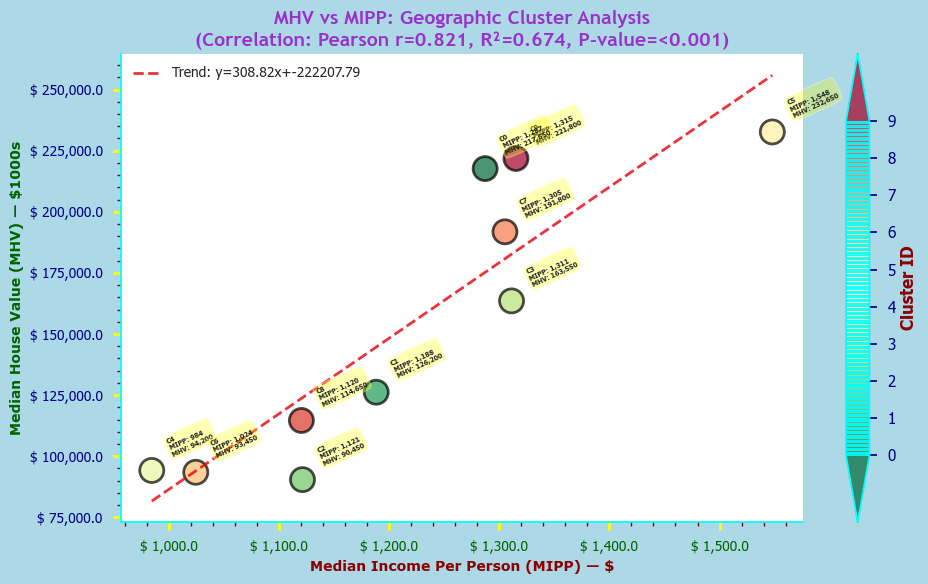

In [228]:
# Scatterplot - Median House Value vs Median Income Per Person: Geographic Cluster Analysis.

# Create figure
fig, gcsp1 = plt.subplots(figsize=(10, 6))

# Scatter plot
scatter = gcsp1.scatter(pivot_df['MIPP'], pivot_df['MHV'], 
                     s=300, 
                     c=pivot_df['Cluster'], 
                     cmap='RdYlGn_r',
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=2)
# Add cluster labels
for idx, row in pivot_df.iterrows():
    gcsp1.annotate(f"C{int(row['Cluster'])}\nMIPP: {int(row['MIPP']):,.0f}\nMHV: {int(row['MHV']):,.0f}",
                xy=(row['MIPP'], row['MHV']), # row['MHV']/1000
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=5,
                fontweight='bold',rotation=25,
                bbox=dict(boxstyle='round4,pad=0.5', facecolor='yellow', alpha=0.3))

# Add trend line
z = np.polyfit(pivot_df['MIPP'], pivot_df['MHV'], 1) # pivot_df['MHV']/1000
p = np.poly1d(z)
x_trend = np.linspace(pivot_df['MIPP'].min(), pivot_df['MIPP'].max(), 100)
gcsp1.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

# Labels & formatting
gcsp1.set_title('MHV vs MIPP: Geographic Cluster Analysis\n(Correlation: Pearson r=0.821, R²=0.674, P-value=<0.001)', fontsize=14, fontweight='bold', fontdict=title_font)
gcsp1.set_xlabel('Median Income Per Person (MIPP) — $', fontsize=10, fontweight='bold', fontdict=x_label_font)
gcsp1.set_ylabel('Median House Value (MHV) — \$1000s', fontsize=10, fontweight='bold', fontdict=y_label_font)
gcsp1.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
gcsp1.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
gcsp1.minorticks_on()
gcsp1.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gcsp1.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gcsp1.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gcsp1.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

# Grid
gcsp1.grid(True, alpha=0.3, linestyle='--')

# Format colobar value
fmt = lambda x,pos: '{:,.0f}'.format(x)

# Keyword arguements for colorbar appearance
cbar_kws = {"orientation":"vertical", "shrink":1.0, 'extend':'both', 'extendfrac':0.2, "drawedges":True, 'label':'Cluster ID', 'spacing':'uniform', 'format':fmt}

# Color bar
cbar = plt.colorbar(scatter, ax=gcsp1, **cbar_kws) # label='Cluster ID'
cbar.set_label('Cluster ID', fontsize=12, fontweight='bold', color='darkred')

# Legend
gcsp1.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

**`Scatterplot - Median House Value vs Median Income: Geographic Cluster Analysis`**.

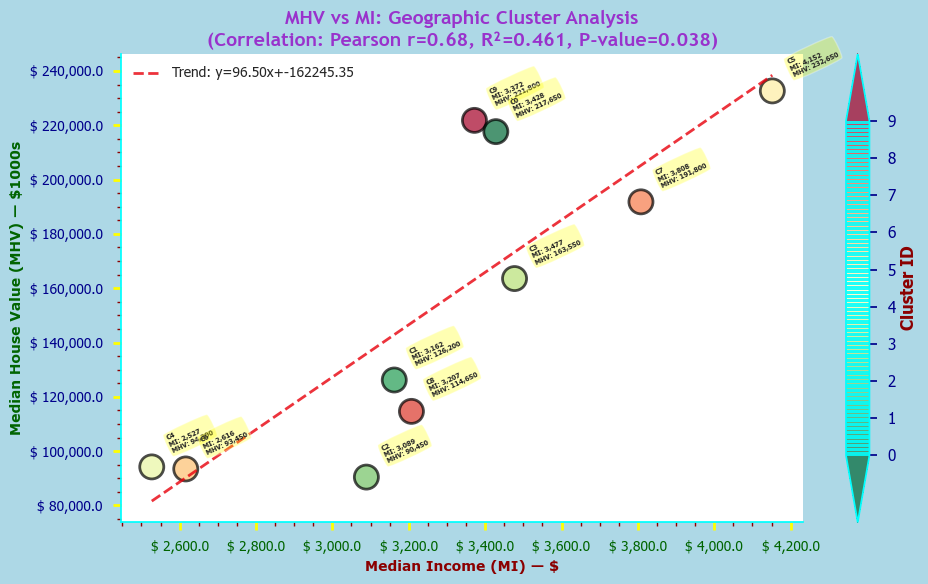

In [229]:
# Scatterplot - Median House Value vs Median Income: Geographic Cluster Analysis.

# Create figure
fig, gcsp2 = plt.subplots(figsize=(10, 6))

# Scatter plot
scatter = gcsp2.scatter(pivot_df['MI'], pivot_df['MHV'], 
                     s=300, 
                     c=pivot_df['Cluster'], 
                     cmap='RdYlGn_r',
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=2)
# Add cluster labels
for idx, row in pivot_df.iterrows():
    gcsp2.annotate(f"C{int(row['Cluster'])}\nMI: {int(row['MI']):,.0f}\nMHV: {int(row['MHV']):,.0f}", 
                xy=(row['MI'], row['MHV']), # row['MHV']/1000
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=5,
                fontweight='bold', rotation=25,
                bbox=dict(boxstyle='round4,pad=0.5', facecolor='yellow', alpha=0.3))

# Add trend line
z = np.polyfit(pivot_df['MI'], pivot_df['MHV'], 1) # pivot_df['MHV']/1000
p = np.poly1d(z)
x_trend = np.linspace(pivot_df['MI'].min(), pivot_df['MI'].max(), 100)
gcsp2.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

# Labels & formatting
gcsp2.set_title('MHV vs MI: Geographic Cluster Analysis\n(Correlation: Pearson r=0.68, R²=0.461, P-value=0.038)', fontsize=14, fontweight='bold', fontdict=title_font)
gcsp2.set_xlabel('Median Income (MI) — $', fontsize=10, fontweight='bold', fontdict=x_label_font)
gcsp2.set_ylabel('Median House Value (MHV) — \$1000s', fontsize=10, fontweight='bold', fontdict=y_label_font)
gcsp2.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
gcsp2.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
gcsp2.minorticks_on()
gcsp2.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gcsp2.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gcsp2.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gcsp2.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

# Grid
gcsp2.grid(True, alpha=0.3, linestyle='--')

# Format colobar value
fmt = lambda x,pos: '{:,.0f}'.format(x)

# Keyword arguements for colorbar appearance
cbar_kws = {"orientation":"vertical", "shrink":1.0, 'extend':'both', 'extendfrac':0.2, "drawedges":True, 'label':'Cluster ID', 'spacing':'uniform', 'format':fmt}

# Color bar
cbar = plt.colorbar(scatter, ax=gcsp2, **cbar_kws) # label='Cluster ID'
cbar.set_label('Cluster ID', fontsize=12, fontweight='bold', color='darkred')

# Legend
gcsp2.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

**`📊 Key Insights`**:
- --
 - **`Map 1 — Median House Value, Income & Income Per Person Per Geographic Cluster`**.
- -- 
   - **`🏆 Tier 1 (Highest) — Alameda County (C5, MHV\$232.65k | MIPP\$1.55K | MI\$4.15k) — 1st by Median House Value, Median Income Per Person & Median Income`**.

   - **`🥈 Tier 2 (High) — Santa Barbara County (C9, MHV\$221.80k | MIPP\$1.31K | MI\$3.37k) — 2nd by Median House Value, Median Income Per Person & Median Income`**.

   - **`🥉 Tier 3 (Mid-High) — Los Angeles County (C0, MHV\$217.65k | MIPP\$1.29K | MI\$3.43k) — 3rd by Median House Value, 5th by Median Income Per Person & Median Income`**.

   - **`4️⃣ Tier 4 (Mid) — Orange County (C7, MHV\$191.80k | MIPP\$1.30k | MI\$3.81k) — 4th by Median House Value, Median Income Per Person & Median Income`**.

   - **`5️⃣ Tier 5 (Mid-Low) — San Diego County (C3, MHV\$163.55k | MIPP\$1.31k | MI\$3.48k) — 5th by Median House Value, 3rd by Median Income Per Person & Median Income`**.
   
   - **`6️⃣ Tier 6 (Low) — Sacramento County (C1, MHV\$126.20k | MIPP\$1.19k | MI\$3.16k) — 6th by Median House Value, Median Income Per Person & Median Income`**.

   - **`7️⃣ Tier 7 (4th Lowest) — San Bernardino County (C8, MHV\$114.65k | MIPP\$1.12k | MI\$3.21k) — 7th by Median House Value, 8th by Median Income Per Person & Median Income`**.

   - **`8️⃣ Tier 8 (3rd Lowest) — Humboldt County (C4, MHV\$94.20k | MIPP\$0.98k | MI\$2.53k) — 8th by Median House Value, 10th by Median Income Per Person & Median Income`**.

   - **`9️⃣ Tier 9 (2nd Lowest) — Butte County (C6, MHV\$93.45k | MIPP\$1.02k | MI\$2.62k) — 9th by Median House Value, Median Income Per Person & Median Income`**.

   - **`🔟 Tier 10 (Lowest) — Tulare County C2, MHV\$90.45k | MIPP\$1.12k | MI\$3.09k) — 10th by Median House Value, 7th by Median Income Per Person & Median Income`**.
   
- --
**`🎯 General Pattern`**:
- --
  - **`📈 Coastal Tier Dominace (Tier 1-5)`**: **`All top 5 clusters are coastal or major metro areas | MHV range: $163.55k - $232.65k | Average MHV: $199k`**.

  - **`📉 Inland/Rural Tier Collapse (Tiers 6-10)`**: **`All bottom 5 clusters are inland or rural | MHV range: $90.45k - $126.20k | Average MHV: $106k`**.

  - **`⚖️ Ratio`**: **`Coastal areas command 1.88x higher median house values`**.
- --
**`💡 Key Takeaway`**:
- --
  - **`Coastal desirability creates artificial scarcity, driving house values up disproportionately to income earned`**. 

  - **`Inland areas offer better value propositions but lack demand premium`**.
- --

**`Plotly Geospatial Map`**

In [230]:
# import plotly.graph_objects as go
# import pandas as pd
# import numpy as np

# # ══════════════════════════════════════════════════════════════════════════════
# # STEP 1: Compute Cluster Centers & Median Stats
# # ══════════════════════════════════════════════════════════════════════════════
# centers = (
#     final.groupby('Cluster')
#     .agg(
#         lat_center    = ('latitude',            'mean'),
#         lon_center    = ('longitude',           'mean'),
#         mhv_median    = ('median_house_value',  'median'),
#         ipp_median    = ('income_per_person',   'median'),
#         mi_median     = ('median_income',       'median'),
#         location_name = ('location_name',       lambda x: x.value_counts().index[0]),
#     )
#     .reset_index()
# )

# # # ── Cluster Centre Box Labels ─────────────────────────────────────────────────
# # centers['label'] = centers.apply(lambda r: (
# #     f"C-{r['Cluster']}  {r['location_name']}<br>"
# #     f"MHV: (${r['mhv_median']/1000:.2f}k)<br>"
# #     f"MEIPP: (${r['ipp_median']/1000:.2f}k)<br>"
# #     f"ME: (${r['mi_median']/1000:.2f}k)"
# # ), axis=1)

# # ── Fix both label columns safely ─────────────────────────────────────────────
# def make_center_label(r):
#     return (
#         f"C-{r['Cluster']}  {r['location_name']}<br>"
#         f"MHV: (${r['mhv_median']/1000:.2f}k)<br>"
#         f"MEIPP: (${r['ipp_median']/1000:.2f}k)<br>"
#         f"ME: (${r['mi_median']/1000:.2f}k)"
#     )

# # # ── Coordinate Labels (shown below centers) ───────────────────────────────────
# # centers['coord_label'] = centers.apply(lambda r:
# #     f"Lat:({r['lat_center']:.1f})<br>Long:({r['lon_center']:.1f})"
# # , axis=1)

# def make_coord_label(r):
#     return f"Lat:({r['lat_center']:.1f})<br>Long:({r['lon_center']:.1f})"

# centers['label']       = centers.apply(make_center_label, axis=1)
# centers['coord_label'] = centers.apply(make_coord_label,  axis=1)


# # ══════════════════════════════════════════════════════════════════════════════
# # STEP 2: Custom Colorscale (matches image colorbar 0-9)
# # ══════════════════════════════════════════════════════════════════════════════
# custom_colorscale = [
#     [0.00, "#FF7F0E"],   # 0  — orange
#     [0.11, "#20B2AA"],   # 1  — light sea green / teal
#     [0.22, "#FF4500"],   # 2  — orange-red
#     [0.33, "#FF69B4"],   # 3  — hot pink
#     [0.44, "#C8A96E"],   # 4  — tan / khaki
#     [0.55, "#909090"],   # 5  — grey
#     [0.66, "#9370DB"],   # 6  — medium purple
#     [0.77, "#ADFF2F"],   # 7  — yellow-green
#     [0.88, "#FFD700"],   # 8  — gold / yellow
#     [1.00, "#00CED1"],   # 9  — dark turquoise / cyan
# ]


# # ══════════════════════════════════════════════════════════════════════════════
# # STEP 3: Build Figure
# # ══════════════════════════════════════════════════════════════════════════════
# fig = go.Figure()


# # ── TRACE 1: Individual Property Scatter Points ───────────────────────────────
# fig.add_trace(go.Scattermapbox(
#     lat        = final['latitude'],
#     lon        = final['longitude'],
#     mode       = 'markers',
#     name       = 'Properties',
#     showlegend = False,
#     marker     = dict(
#         size       = 5,
#         color      = final['Cluster'],
#         colorscale = custom_colorscale,
#         cmin       = 0,
#         cmax       = 9,
#         opacity    = 0.65,
#         showscale  = True,
#         colorbar   = dict(
#             title      = dict(
#                 text = "<b>Cluster</b>",
#                 side = "right",
#                 font = dict(family="Tahoma", size=13, color="black"),
#             ),
#             thickness  = 22,
#             len        = 0.80,
#             tickvals   = list(range(10)),
#             ticktext   = [str(i) for i in range(10)],
#             tickfont   = dict(family="Tahoma", size=11),
#             x          = 1.01,
#             bgcolor    = "white",
#             bordercolor= "black",
#             borderwidth= 1,
#         ),
#     ),
#     customdata     = final[['location_name', 'Cluster',
#                              'median_house_value',
#                              'income_per_person',
#                              'median_income']].values,
#     hovertemplate  = (
#         "<b>%{customdata[0]}</b><br>"
#         "Cluster : %{customdata[1]}<br>"
#         "Lat: %{lat:.3f}  |  Lon: %{lon:.3f}<br>"
#         "──────────────────────<br>"
#         "MHV : $%{customdata[2]:,.0f}<br>"
#         "Income / Person : $%{customdata[3]:,.0f}<br>"
#         "Median Income : $%{customdata[4]:,.0f}<br>"
#         "<extra></extra>"
#     ),
# ))


# # ── TRACE 2: Cluster Center Markers (red circles) ────────────────────────────
# fig.add_trace(go.Scattermapbox(
#     lat        = centers['lat_center'],
#     lon        = centers['lon_center'],
#     mode       = 'markers',
#     name       = 'Cluster Centers',
#     marker     = dict(
#         size    = 20,
#         color   = 'red',
#         opacity = 0.90,
#     ),
#     customdata     = centers[['Cluster', 'location_name',
#                                'mhv_median', 'ipp_median', 'mi_median']].values,
#     hovertemplate  = (
#         "<b>Cluster Centre — C-%{customdata[0]}</b><br>"
#         "Location : %{customdata[1]}<br>"
#         "Lat: %{lat:.2f}  |  Lon: %{lon:.2f}<br>"
#         "──────────────────────<br>"
#         "MHV Median : $%{customdata[2]:,.0f}<br>"
#         "Income / Person : $%{customdata[3]:,.0f}<br>"
#         "Median Income : $%{customdata[4]:,.0f}<br>"
#         "<extra></extra>"
#     ),
# ))


# # ── TRACE 3: Cluster Centre Info Labels (top-right of marker) ─────────────────
# fig.add_trace(go.Scattermapbox(
#     lat          = centers['lat_center'],
#     lon          = centers['lon_center'],
#     mode         = 'text',
#     text         = centers['label'],
#     textposition = 'top right',
#     name         = 'Centre Labels',
#     hoverinfo    = 'skip',
#     showlegend   = False,
#     textfont     = dict(family="Tahoma", size=11, color="black"),
# ))


# # ── TRACE 4: Lat / Lon Coordinate Labels (bottom-left of marker) ──────────────
# fig.add_trace(go.Scattermapbox(
#     lat          = centers['lat_center'],
#     lon          = centers['lon_center'],
#     mode         = 'text',
#     text         = centers['coord_label'],
#     textposition = 'bottom left',
#     name         = 'Coordinates',
#     hoverinfo    = 'skip',
#     showlegend   = False,
#     textfont     = dict(family="Tahoma", size=10, color="red"),
# ))


# # ══════════════════════════════════════════════════════════════════════════════
# # STEP 4: Layout
# # ══════════════════════════════════════════════════════════════════════════════
# fig.update_layout(

#     title = dict(
#         text     = (
#             "<b>California Housing</b><br>"
#             "<b>Median (House Value, Income & Income Per Person)</b><br>"
#             "<b>Per Geographic Cluster</b>"
#         ),
#         x        = 0.5,
#         xanchor  = "center",
#         font     = dict(family="Tahoma", size=16, color="purple"),
#     ),

#     # ── Map Style ─────────────────────────────────────────────────────────────
#     mapbox = dict(
#         style  = "open-street-map",          # ✅ FREE — no token needed
#         center = dict(lat=37.2, lon=-119.5), # California centre
#         zoom   = 5.2,
#     ),

#     # ── Legend (Cluster Centers) ──────────────────────────────────────────────
#     legend = dict(
#         title       = dict(
#             text = "<b>Cluster Centers</b>",
#             font = dict(family="Tahoma", size=13, color="black"),
#         ),
#         bgcolor     = "white",
#         bordercolor = "black",
#         borderwidth = 2,
#         x           = 0.75,
#         y           = 0.98,
#         font        = dict(family="Tahoma", size=11),
#     ),

#     # ── Canvas ────────────────────────────────────────────────────────────────
#     width  = 1000,
#     height = 820,
#     margin = dict(t=130, b=20, l=10, r=80),
#     font   = dict(family="Tahoma"),
# )


# # ══════════════════════════════════════════════════════════════════════════════
# # STEP 5: Save Options (uncomment as needed)
# # ══════════════════════════════════════════════════════════════════════════════
# # fig.write_html("CA_Housing_Cluster_Map.html")
# # fig.write_image("CA_Housing_Cluster_Map.png",  width=1200, height=900, scale=2)
# # fig.write_image("CA_Housing_Cluster_Map.pdf",  width=1920, height=1080, scale=2)

# fig.show()

**`Map Location Name Directly Using The Cluster Column`**.

In [231]:
# Map directly using the Cluster column
final['location_name'] = final['Cluster'].map(location_names)
final.sample(1)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity,MHV_cluster,MHV_cluster_name,price_cluster,price_cluster_name,wealth_cluster,wealth_cluster_name,geo_cluster,geo_cluster_name,market_segment_cluster,market_segment_cluster_name,Risk,Return,Best Strategy,Annotated Summary,Cluster,Best Strategy Short,location_name
8718,-122.55,38.81,1027.0,421.0,3639.0,637.0,2.43943,8.643705,3.54333,1591.806329,0.175048,7.0,3883.1,132100.0,INLAND,0,🏘️ Budget,0,🏘️ Affordable Neighborhoods,0,🏘️ Budget Communities,0,Northern California,1,🌊 Affordable SoCal Coastal,Medium,Low-Medium,Affordable Development,🔄 Affordable Development,6,AFD,Butte County


**`Preview Location Name Values`**.

In [232]:
final[final['location_name']=='Los Angeles County'].loc[:,['Cluster', 'income_per_person','location_name']].sample(1) # Sample display rows of specific columns
# # final[final['location_name']=='Newark'].loc[:,'longitude':'location_name'].sample(1) Display sample rows of specified column range

,Cluster,income_per_person,location_name
8183,0,2816.843575,Los Angeles County


**`Boxplot - Distribution of Total Median House Value By Location & Best Housing Strategy (Plotly)`**.

In [233]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.box(
    final,
    x="location_name",
    y="median_house_value",
    color="Best Strategy",

    # Fomat hover_data values
    hover_data={
        "Cluster": True,                   # no format change
        #"MHV_cluster_name": True,          # no format change
        #"price_cluster_name": True,        # no format change
        #"wealth_cluster_name": True,       # no format change
        "income_per_person": ":$,.2f",     # ✅ formatted as \$1,234
        "median_income": ":$,.2f",         # ✅ formatted as \$1,234
        #"rooms_per_person": ":,.2f",       # ✅ formatted as \1,234
        #"rooms_per_house": ":,.2f",        # ✅ formatted as \1,234
        "geo_cluster_name": True,          # no format change
        #"housing_median_age": ":,.2f",     # ✅ formatted as \1,234
        #"latitude": True,                  # no format change
        #"longitude": True,                 # no format change
        #"people_per_house": ":,.2f",       # ✅ formatted as \1,234
        #"bedrooms_ratio": ":,.2f",         # ✅ formatted as \1,234
        #"Risk": True,                      # no format change
        #"Return": True,                    # no format change
        "Best Strategy": True,             # no format change
    },
    points="all",
    notched=True,                # ✅ Shows 95% CI around the median
    color_discrete_map={
        "PB&H": "#2ecc71",   # green — premium
        "F&F":  "#3498db",   # blue — mid
        "AFD":  "#e74c3c"    # red — affordable
    },
)

fig.update_traces(
    marker=dict(
        size=3,              # ✅ Smaller points — less clutter
        opacity=0.3,         # ✅ More transparent — less overlap
        line=dict(width=0.5, color="black")
    ),
    boxmean=True,            # ✅ Dashed line showing mean inside box
    jitter=0.3,              # ✅ Spreads points horizontally — less overlap
    pointpos=0,              # ✅ Centers points within the box
)

fig.update_layout(
    title={
        "text": "<b><u>Distribution of House Values By Location & Best Housing Strategy</u></b>"
                "<br><sup>Points represent individual property values per strategy</sup>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Housing Strategy</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    ),
    boxmode="group",             # ✅ Groups boxes side by side per location
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("boxplot.jpeg")
# fig.write_image("boxplot.svg")
# fig.write_image("boxplot.pdf")
# fig.write_html("boxplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

##### `🏡 California Housing: Ocean Proximity And Median House Value Per Geographic Cluster`.

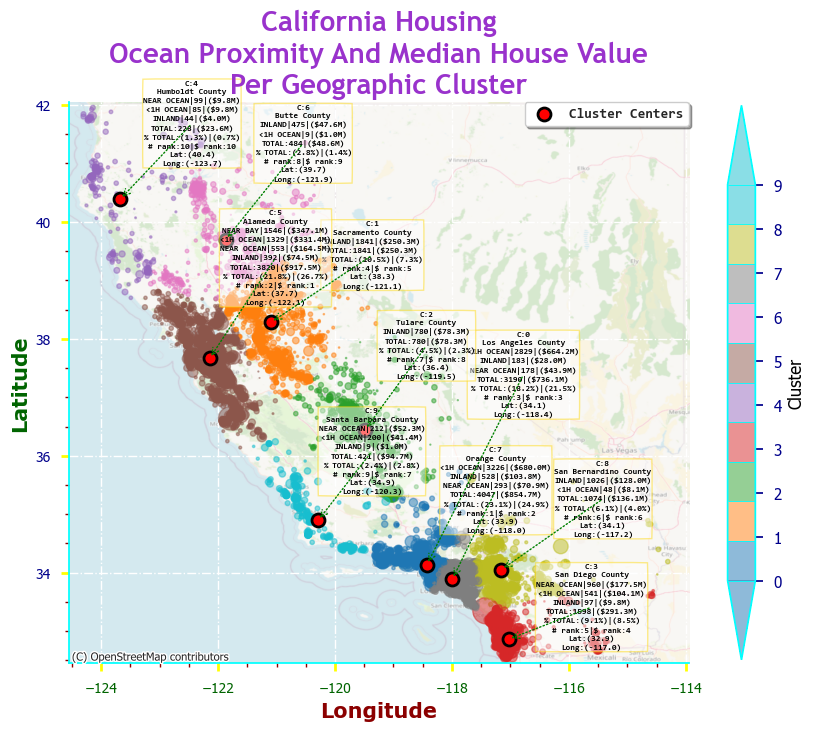

In [234]:
# Geographic cluster visualisation
# - KMeans clustering on lat/lon
# - Median house value & income per cluster
# - OpenStreetMap (via contextily) basemap overlay

#==#

# Fit KMeans on location
kmeans = KMeans(n_clusters=10, random_state=42)
final["Cluster"] = kmeans.fit_predict(final[["latitude", "longitude"]])
median_house_value = final.groupby("Cluster")["median_house_value"].median()
income_per_person = final.groupby("Cluster")["income_per_person"].median()
median_income = final.groupby("Cluster")["median_income"].median()

#==#

# MAP 1 - Median House Value, Median Income and Median Income Per Person Per Geographic Cluster

# Pre-compute median house value sum per Cluster
mhv_cluster_medians = final.groupby("Cluster")["median_house_value"].median()

# Rank across all median house value clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mipp_cluster_medians = final.groupby("Cluster")["income_per_person"].median()

# Rank across all median income per person clusters (highest value = rank 1)
mipp_cluster_ranks = mipp_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mi_cluster_medians = final.groupby("Cluster")["median_income"].median()

# Rank across all ocean_proximity clusters (highest value = rank 1)
mi_cluster_ranks = mi_cluster_medians.rank(ascending=False, method='min').astype(int)

#==#

# MAP 2 - Ocean Proximity and Median House Value Per Geographic Cluster

# Calculate grand totals
grand_total_count = final['ocean_proximity'].value_counts().sum()
grand_total_value = final['median_house_value'].sum()

# Show all ocean proximity, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
ocean_proximity = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{k}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['ocean_proximity'].value_counts().items()])
        + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['ocean_proximity'].value_counts().sum()/grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all mhv clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute total ocean proximity count per Cluster
op_cluster_totals = final.groupby("Cluster")["ocean_proximity"].count()

# Rank across all ocean_proximity clusters (highest value = rank 1)
op_cluster_ranks = op_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# MAP 3 - Housing Strategy and Median House Value Per Geographic Cluster

# Shortened version for cleaner map
strategy_short = {
    'Premium Buy & Hold': 'PB&H',
    'Volume Investment (Fix & Flip)': 'F&F',
    'Affordable Development': 'AFD'
}

# Map shortened names
final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# Calculate grand totals
bs_grand_total_count = final['Best Strategy'].value_counts().sum()
bs_grand_total_value = final['median_house_value'].sum()

# Get all strategies per cluster with shortened names, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
best_strategy = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['Best Strategy'].value_counts().items()])
        + f"\nTOTAL:{x['Best Strategy'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['Best Strategy'].value_counts().sum()/bs_grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/bs_grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
bs_mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all median house value clusters (highest value = rank 1)
bs_mhv_cluster_ranks = bs_mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute best strategy count per Cluster
bs_cluster_totals = final.groupby("Cluster")["Best Strategy Short"].count()

# Rank across all best strategy clusters (highest value = rank 1)
bs_cluster_ranks = bs_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# # MAP 2 - CODE 2
# # Show all ocean proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{[k]}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False)

#==#

# # MAP 2 - CODE 3
# # Show all ocean_proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x['ocean_proximity'].value_counts().items()])
#                          + f"\nCNT:{x['ocean_proximity'].value_counts().sum():,.0f}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.2f}M)", include_groups=False)

#==#

# # MAP 2 - CODE 4
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|{(v/x['ocean_proximity'].value_counts().sum())*100:.1f}%|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)|{(x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum())*100:.1f}%" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:|{x['ocean_proximity'].value_counts().sum()}|100%|(${x['median_house_value'].sum()/1e6:,.1f}M)|100%",
#     include_groups=False)

# print(ocean_proximity)

#==#

# # MAP 2 - CODE 5
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|({v/len(x)*100:.1f}%)|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M ({x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum()*100:.1f}%)" 
#         for k, v in x['ocean_proximity'].value_counts().items()
#     ]) + f"\nTOTAL:{len(x)}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False
# )

# print(ocean_proximity)

#==#

# # MAP 3 - CODE 1
# # Get Best Strategy per Cluster (most common strategy in each cluster)
# best_strategy = final.groupby("Cluster")["Best Strategy"].agg(lambda x: x.value_counts().index[0])

#==#

# # MAP 3 - CODE 2
# # Get all strategies per cluster with their counts
# best_strategy = final.groupby("Cluster")["Best Strategy"].apply(
#     lambda x: '\n'.join([f"{k}({v})" for k, v in x.value_counts().items()])
# )

#==#

# # MAP 3 - CODE 3
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}" for k, v in x.value_counts().items()]), include_groups=False)

#==#

# # MAP 3 - CODE 4
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names and count total
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x.value_counts().items()])
#                          + f"\nCNT:({x.value_counts().sum()})", include_groups=False)

#==#

# # MAP 3 - CODE 5
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x["Best Strategy Short"].value_counts().items()])
#                          + f"\nCNT:{x["Best Strategy Short"].value_counts().sum()}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1000:,.0f}M)", include_groups=False # .sum()/1e6:,.0f}M)"
# )

#==#

# # MAP 3 - CODE 6
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, counts, $ values, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['Best Strategy'].value_counts().items()
#     ]) + 
#     f"\nCNT:{x['Best Strategy'].value_counts().sum()}" +
#     f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.1f}M)", include_groups=False)

#==#

# Plot scatterplot and capture the returned axes
fig, gc2 = plt.subplots(ncols=1, nrows=1, figsize=(10,8), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# Plot
# plt.figure(figsize=(10, 8))
scatter = gc2.scatter(final["longitude"], final["latitude"],
                      c=final["Cluster"], cmap="tab10", # c expects a color-mappable array, while color accepts a simple color string like "red".
                      s=final["population"]/100, alpha=0.5) # Dividing by 100 scales population (e.g 5000, 10000) down to a reasonable dot size range.
plt.scatter(kmeans.cluster_centers_[:, 1], 
            kmeans.cluster_centers_[:, 0],
            c="red", ec='black', marker=".", s=(350), 
            linewidths=2, label="Cluster Centers") 

#==============================================================#

# OLD BUILD - DO NOT USE!!
# # Import Geolocator
# from geopy.geocoders import Nominatim

# # Initialise Geolocator
# geolocator = Nominatim(user_agent="vym1")

# def get_location_name(lat, lon):
#     location = geolocator.reverse(f"{lat}, {lon}")
#     return location.raw['address'].get('city') or \
#            location.raw['address'].get('town') or \
#            location.raw['address'].get('county')


# # Hardcoded location names from previous map
# location_names = {
#     0: "Los Angeles",
#     1: "Newark",
#     2: "Ventura County",
#     3: "Fresno",
#     4: "Sacramento County",
#     5: "Santee",
#     6: "Trinity County",
#     7: "Sonoma County",
#     8: "Chino",
#     9: "Arroyo Grande"
# }

# def get_location_name(lat, lon):
#     return location_names.get(i, f"({lat:.1f}, {lon:.1f})")

#==============================================================#

from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="vym1")

def get_location_name(lat, lon):
    try:
        time.sleep(1)  # ✅ Respect Nominatim rate limit (1 req/sec)
        location = geolocator.reverse(
            f"{lat}, {lon}",
            exactly_one=True,
            language="en",
            zoom=8  # ✅ Key fix: zoom=8 = county/region level, not street level
        )
        if location is None:
            return f"({lat:.1f}, {lon:.1f})"
        
        address = location.raw['address']
        
        # ✅ Walk through from most to least specific regional name
        return (
            address.get('city')        or  # e.g. Los Angeles
            address.get('town')        or  # e.g. smaller towns
            address.get('village')     or  # e.g. rural areas
            address.get('suburb')      or  # e.g. city districts
            address.get('county')      or  # e.g. Trinity County
            address.get('state_district') or
            address.get('state')       or  # fallback to state
            f"({lat:.1f}, {lon:.1f})"     # final fallback
        )
    except Exception as e:
        print(f"Geocoding failed for ({lat}, {lon}): {e}")
        return f"({lat:.1f}, {lon:.1f})"

#==#

# Annotate cluster centers with cluster number, location name, OP MHV $ rank, OP count rank, ocean proximity, OP total MHV, OP total count, longitude & latitude 

# Annotation format properties
arrow_3 = dict(arrowstyle="->", color='green', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
box_3 = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Import adjust_text library
from adjustText import adjust_text

# Pre-build location names BEFORE the loop (avoids repeated API calls)
location_names = {
    i: get_location_name(center[0], center[1])
    for i, center in enumerate(kmeans.cluster_centers_)
}

# Define empty list
texts = []

# Annotate values
for i, center in enumerate(kmeans.cluster_centers_):
    location_name = get_location_name(center[0], center[1])
    texts.append(
        gc2.text(
            center[1] + 0.5,  # Cluster longitude, + 0.5 - Move text East  ➡️,  -0.5 - Move text West  ⬅️
            center[0] + 0.4,  # Cluster latitude, + 0.5 - Move text North ⬆️, -0.5  - Move text South ⬇️
            f"C:{i}\n{location_name}\n{ocean_proximity[i]}\n# rank:{op_cluster_ranks[i]}|$ rank:{mhv_cluster_ranks[i]}\nLat:({center[0]:,.1f})\nLong:({center[1]:,.1f})",
            color='black', fontsize=6, fontweight="bold",
            fontfamily='consolas', fontstyle='normal', rotation=0,
            bbox=box_3
        )
    )

# Auto adjust text positions first
adjust_text(texts, ax=gc2)

# Then draw YOUR arrows from adjusted text positions to cluster centers
for i, (text, center) in enumerate(zip(texts, kmeans.cluster_centers_)):
    # Get adjusted text position
    text_x, text_y = text.get_position()
    
    # Draw arrow from text box to cluster center
    gc2.annotate("",
                xy=(center[1], center[0]),        # ✅ Arrow HEAD at cluster center
                xytext=(text_x, text_y),           # ✅ Arrow TAIL at text box
                arrowprops=arrow_3,                  # ✅ Your original arrow style
                xycoords='data',
                textcoords='data')

#==============================================================#

# # Annotation format properties
# arrow = dict(arrowstyle="]->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
# box = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# # Annotate cluster centers with cluster number
# for i, center in enumerate(kmeans.cluster_centers_):
#     plt.annotate(f"C:{i}",
#                  xy=(center[1], center[0]), xytext=(-35, -15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # # Annotate cluster centers with cluster number, location and ocean_proximity
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc2.annotate(f"C:{i}\n{location_name}\n{ocean_proximity[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
    
# # Annotate cluster centers with cluster number, location, median_house_value, income_per_person and median_income
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc2.annotate(f"C:{i}\n{location_name}\nMHV:(${median_house_value[i]/1000:,.2f}k)\nMIPP:(${income_per_person[i]/1000:,.2f}k)\nMI:(${median_income[i]/1000:,.2f}k)",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with cluster number, location and best strategy
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc2.annotate(f"C:{i}\n{location_name}\n{best_strategy[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with longitiude and latitude
# for i, center in enumerate(kmeans.cluster_centers_):
#     gc2.annotate(f"\nLat:({center[0]:,.1f})\nLong:({center[1]:,.1f})",
#                  xy=(center[1], center[0]), xytext=(-25, -25), textcoords="offset points", ha='center', va='center',
#                  color='red', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
         
#==#

#==============================================================#

# OLD PLOT
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("California Housing - Location Clusters")
# plt.legend()
# plt.show()

#==============================================================#

# Format colobar value
fmt = lambda x,pos: '{:,.0f}'.format(x)

# Keyword arguements for colorbar appearance
cbar_kws = {"orientation":"vertical", "shrink":0.9, 'extend':'both', 'extendfrac':0.2, "drawedges":True, 'label':'Cluster', 'spacing':'uniform', 'format':fmt}

# Plot colobar
plt.colorbar(scatter, ax=gc2, **cbar_kws) # label='Cluster'

# Set plot legend properties
title_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = gc2.legend(loc='best',bbox_to_anchor=(1, 1),borderaxespad=0,title='',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

# Set plot axes properties
gc2.set_title('California Housing'+'\nOcean Proximity And Median House Value'+'\nPer Geographic Cluster',loc='center', fontdict=title_font)
gc2.set_xlabel('Longitude', loc='center', fontdict=x_label_font) # Independent Variable
gc2.set_ylabel('Latitude', loc='center', fontdict=y_label_font) # Dependent Variable
# gc2.grid(linestyle='dashdot', color='pink', linewidth=0.5)
# gc2.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
# gc2.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
gc2.minorticks_on()
gc2.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gc2.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gc2.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gc2.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# gc2.autoscale()
# gc2.axis('equal')
# gc2.set_xlim(left=0)
# gc2.set_ylim(bottom=0)
# gc2.set_xscale('log')
# gc2.set_yscale('log')
# gc2.set_yscale('linear')  # Try removing log scale

#==#

# Add map tile as background
from pathlib import Path
import contextily as ctx
ctx.add_basemap(gc2, 
                crs="EPSG:4326",  # lat/lon coordinate system
                source=ctx.providers.OpenStreetMap.Mapnik,alpha=0.5)

gc2.set_xlim(-124.55, -113.95)
gc2.set_ylim(32.45, 42.05)

#==#

# filename = "Map.png"
# filepath = Path("C:/Users/tailb/Downloads/Map.png")
# california_img = plt.imread(filepath)
# axis = -124.55, -113.95, 32.45, 42.05
# plt.imshow(california_img, extent=axis, alpha=0.5)  # background first
# plt.axis(axis)

#==#

# my_path = r"\Users\tailb\Downloads"
# plt.savefig(my_path + '/Map2.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Ocean_Proximity_And_MHV_Per_Geographic_Cluster_Geospatial_KMeans_Cluster_Bubble_Map.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Display plot
plt.show()

**`🗺️ Key Insights`**:
- --
 - **`Map 2 — Ocean Proximity, Count and Median House Value Per Geographic Cluster`**.
- -- 
   - **`🏆 Tier 1 (Highest) — Alameda County (C5, \$917.5M | 26.7% | 3,820 count | 21.8%) — 1st by ($) value, 2nd by (#) count`**.

   - **`🥈 Tier 2 (High) — Orange County (C7, \$854.7M | 24.9% | 4,047 count | 23.1%) — 2nd by ($) value and 1st by (#) count`**.

   - **`🥉 Tier 3 (Mid-High) — Los Angeles County (C0, \$736.1M| 21.5% | 3,190 count | 18.2%) — 3rd by ($) value and 3rd by (#) count`**.

   - **`4️⃣ Tier 4 (Mid) — San Diego County (C3, \$291.3M | 8.5% | 1,598 count | 9.1%) and Sacramento County (C1, \$250.3M | 7.3% | 1,841 count | 10.5%)`**.

   - **`5️⃣ Tier 5 (Mid-Low) — San Bernardino County (C8, \$136.1M | 4.0% | 1,074 count | 6.1%) and Santa Barbara County (C9, \$94.7M | 2.8% | 421 count | 2.4%)`**.
   
   - **`6️⃣ Tier 6 (Lowest) — Tulare County (C2, \$78.3M | 2.3% | 780 count | 4.5%), Butte County (C6, \$48.6M | 1.4% | 484 count | 2.8%) and Humboldt County (C4, \$23.6M | 0.7% | 228 count | 1.3%)`**.
- --
**`🎯 General Pattern`**:
- --
  - **`📈 Coastal areas`** = **`higher prices`**.

  - **`📉 Inland/Rural areas`** = **`lower prices`**.

  - **`This confirms that location is a strong predictor of house prices! 🏠`**.
- --

**`Cluster, Location Name And Ocean Proximity Median House Value Statistics`**.

In [235]:
c_loc_op = final.groupby(['Cluster', 'location_name', 'ocean_proximity'])['median_house_value']\
    .agg(['count', 'min', 'max', 'mean', 'median', 'sum']).sort_values(by='sum', ascending=False).round(2).reset_index()\
        .assign(proportion=lambda x: x["count"] / x["count"].sum())
#c_loc_op['avg_$_per_prop'] = (c_loc_op['sum'] / c_loc_op['count']).round(2)
c_loc_op['count_rank'] = c_loc_op['count'].rank(ascending=False)
c_loc_op['median_rank'] = c_loc_op['median'].rank(ascending=False) 
c_loc_op['sum_rank'] = c_loc_op['sum'].rank(ascending=False) 
c_loc_op

# # Styled - Not for plotting!!
# c_loc_op = final.groupby(['Cluster', 'location_name', 'ocean_proximity'])['median_house_value'].agg(['count', 'min', 'max', 'mean', 'median', 'sum'])\
#     .sort_values(by='sum', ascending=False).reset_index()\
#         .assign(proportion=lambda x: x["sum"] / x["sum"].sum()).style.format({'count':'{:,.0f}', 'mean':'${:,.0f}',, 'median':'${:,.0f}', 'sum':'${:,.0f} M', 'proportion':'{:.2%}'})
# c_loc_op

#==#

# c_loc_op = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())
# )
# c_loc_op

# # Styled - Not for plotting!!
# c_loc_op = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())\
# .style.format({"count": "{:,.0f}", "proportion": "{:.2%}"})
# )
# c_loc_op

,Cluster,location_name,ocean_proximity,count,min,max,mean,median,sum,proportion,count_rank,median_rank,sum_rank
0,7,Orange County,<1H OCEAN,3226,67500.0,487200.0,210782.61,193600.0,679984700.0,0.184522,1.0,8.0,1.0
1,0,Los Angeles County,<1H OCEAN,2829,67500.0,489800.0,234780.24,221000.0,664193300.0,0.161814,2.0,5.0,2.0
2,5,Alameda County,NEAR BAY,1546,67500.0,489600.0,224496.51,204800.0,347071600.0,0.088429,4.0,7.0,3.0
3,5,Alameda County,<1H OCEAN,1329,67500.0,485300.0,249350.41,241900.0,331386700.0,0.076017,5.0,3.0,4.0
4,1,Sacramento County,INLAND,1841,66300.0,475000.0,135966.59,126200.0,250314500.0,0.105302,3.0,16.0,5.0
5,3,San Diego County,NEAR OCEAN,960,67500.0,488900.0,184879.48,159250.0,177484300.0,0.054910,7.0,13.0,6.0
6,5,Alameda County,NEAR OCEAN,553,87500.0,487100.0,297429.11,281500.0,164478300.0,0.031631,9.0,1.0,7.0
7,8,San Bernardino County,INLAND,1026,66300.0,403300.0,124756.24,113750.0,127999900.0,0.058686,6.0,17.0,8.0
8,3,San Diego County,<1H OCEAN,541,80000.0,477600.0,192407.39,174600.0,104092400.0,0.030944,10.0,10.0,9.0
9,7,Orange County,INLAND,528,79200.0,486800.0,196516.67,166300.0,103760800.0,0.030201,11.0,12.0,10.0


**`Barplot - Property Count By Location Name And Ocean Proximity`**.

'Orange County' - 1st, <1H OCEAN, 3,226, 679,984,700, 18.45%
'Los Angeles County' - 2nd, <1H OCEAN, 2,829, 664,193,300, 16.18%
'Sacramento County' - 3rd, INLAND, 1,841, 250,314,500, 10.53%


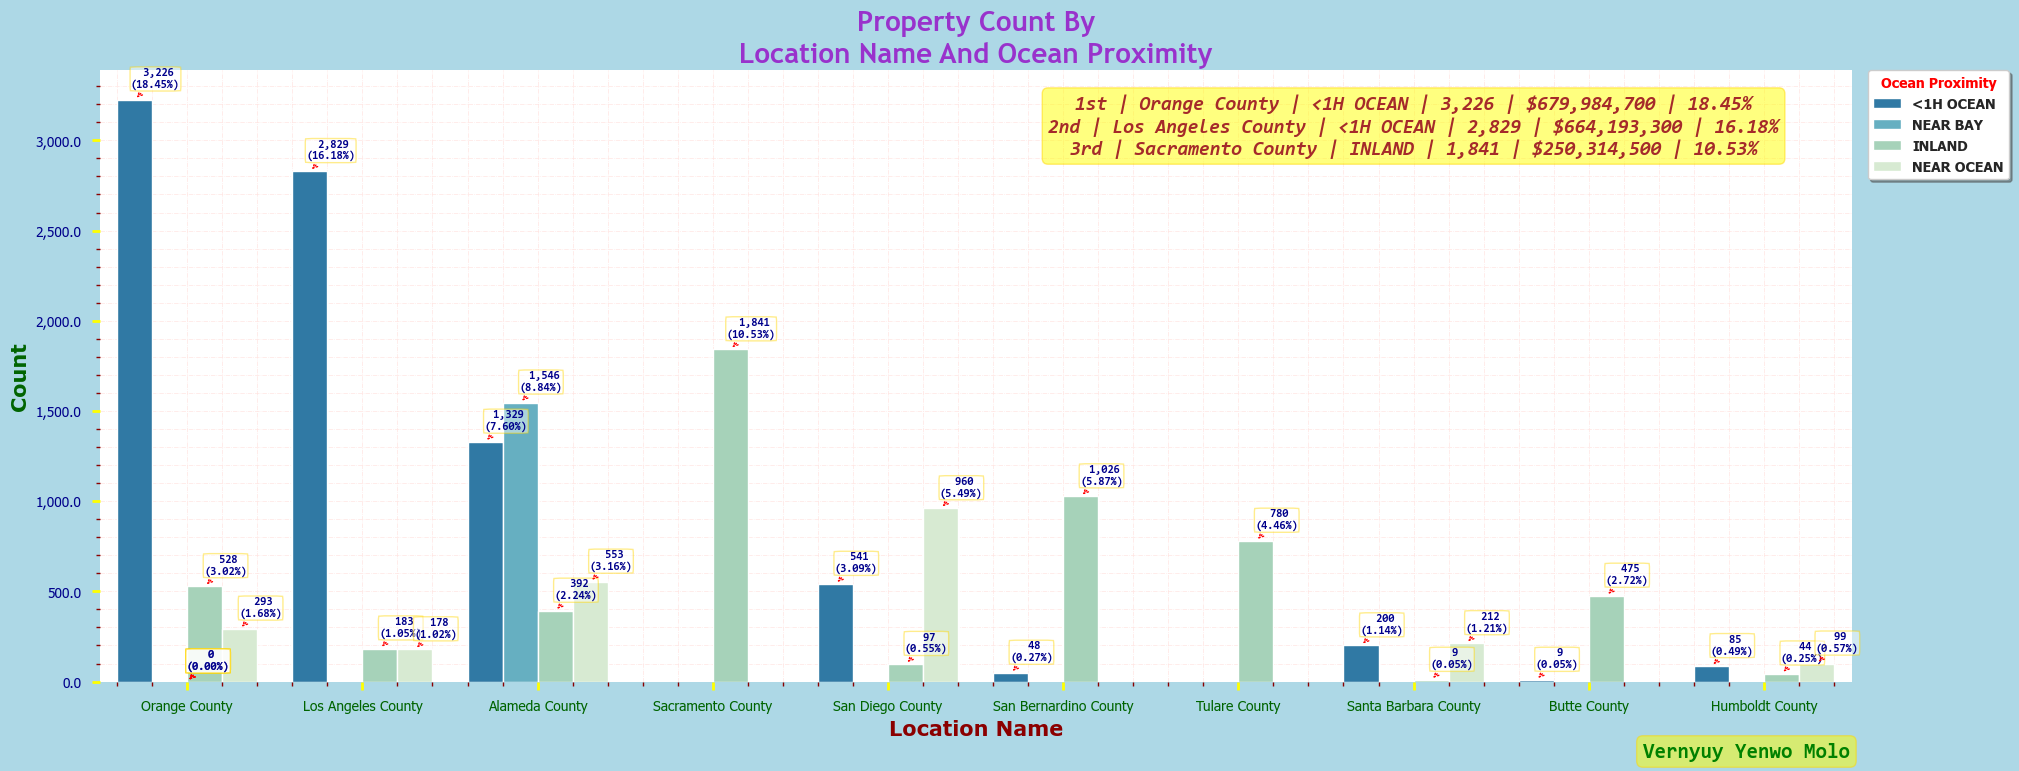

In [236]:
# Barplot - Property Count By Location Name And Ocean Proximity.

# Step 1: Exclude the 'location_name' row by label, not by position before plotting
c_loc_op = c_loc_op.loc[c_loc_op['location_name'].notna()]

#==#

# Step 2 : Plot barplot
g = sns.catplot(data=c_loc_op,x='location_name',y='count',hue='ocean_proximity',row=None,col=None,kind='bar',estimator='sum',errorbar=('ci', 95),n_boot=1000,
seed=None,units=None,weights=None,order=None,hue_order=None,row_order=None,col_order=None,col_wrap=None,height=5,aspect=2,log_scale=None,native_scale=False,formatter=None,
orient=None,color=None,palette='GnBu_r',hue_norm=None,legend='full',legend_out=False,sharex=False,sharey=False,margin_titles=False,facet_kws=None,edgecolor=None,
saturation=0.75,fill=True,width=0.8,dodge='auto',gap=0,capsize=0,err_kws=None,)

#==#

# Step 3: Set figure size
g.figure.set_size_inches(20, 7.5)
# g.figure.set_size_inches(15, 7.5)

#==#
 
# Step 4: Access the underlying axes
axes = g.axes.flatten()

#==#

# Step 5 : Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
for ax in g.axes.flat:
    ax.set_title('Property Count By\n' + 'Location Name And Ocean Proximity', loc='center', fontdict=title_font)
    ax.set_xlabel('Location Name', loc='center', fontdict=x_label_font)
    ax.set_ylabel('Count', loc='center', fontdict=y_label_font)
    # ax.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
    ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
    ax.minorticks_on()
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_visible(False)
    ax.set_facecolor('white')
    ax.grid(which='both',linestyle='dashdot', color='mistyrose',linewidth=0.5)
    # ax.autoscale()
    # ax.axis('equal')
    # ax.set_xlim(left=0)
    # ax.set_ylim(bottom=0)
    # ax.set_ylim(0,355000)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_yscale('linear')  # Try removing log scale

title_props=dict(family='tahoma', style='normal', weight='bold', size='small')
legend_props=dict(family='tahoma', style='normal', weight='bold', size='small')
# sns.move_legend(g,"upper left", bbox_to_anchor=(0.99, 0.96), borderaxespad=0, title='Ocean Proximity', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend = ax.legend(loc='best', bbox_to_anchor=(1.09, 1), borderaxespad=0, title='Ocean Proximity', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend.get_title().set_color("red")

#==#

# Step 6: Annotate values and percentages in arrow & bbox circle format - £/%.

# Annotation format properties
arrow = dict(arrowstyle="->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3,rad=0')
box=dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Annotate the bars
ax = g.facet_axis(0, 0)  # Since we don't have row or col, it's always (0, 0)
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2 
    y = p.get_height()
    ax.annotate(f' {y:,.0f}\n({y/ c_loc_op["count"].sum():.2%})', (x, y), xytext=(15, 15),
                ha='center', va='center', fontfamily='consolas', fontstyle='normal', fontsize=8, fontweight='bold', color='darkblue', rotation=0,
                textcoords='offset points', arrowprops=arrow, bbox=box)

# #==#

# Step 7: Add signature to figure in bbox round format
ax.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ax.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

# #==#

# Step 8: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean = c_loc_op.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by count in descending order and select top 3
top_counts = df_clean.sort_values(by='count', ascending=False).head(3) # count

# Display the top 3 highest counts
for i, row in top_counts.iterrows():
    rank = ['1st', '2nd', '3rd'][top_counts.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['ocean_proximity']}, {row['count']:,.0f}, {row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['ocean_proximity']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_counts.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
ax.annotate(annotation_text,xy=(7, 2900),xytext=(7, 2900),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))

# #==#

# # Step 9: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Property_Count_By_Location_Name_And_Ocean_Proximity_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# #==#

# Step 10: Display plot
plt.show()

**`Barplot - Total Median House Value By Location Name And Ocean Proximity`**.

'Orange County' - 1st, <1H OCEAN, 3,226, $679,984,700, 18.45%
'Los Angeles County' - 2nd, <1H OCEAN, 2,829, $664,193,300, 16.18%
'Alameda County' - 3rd, NEAR BAY, 1,546, $347,071,600, 8.84%


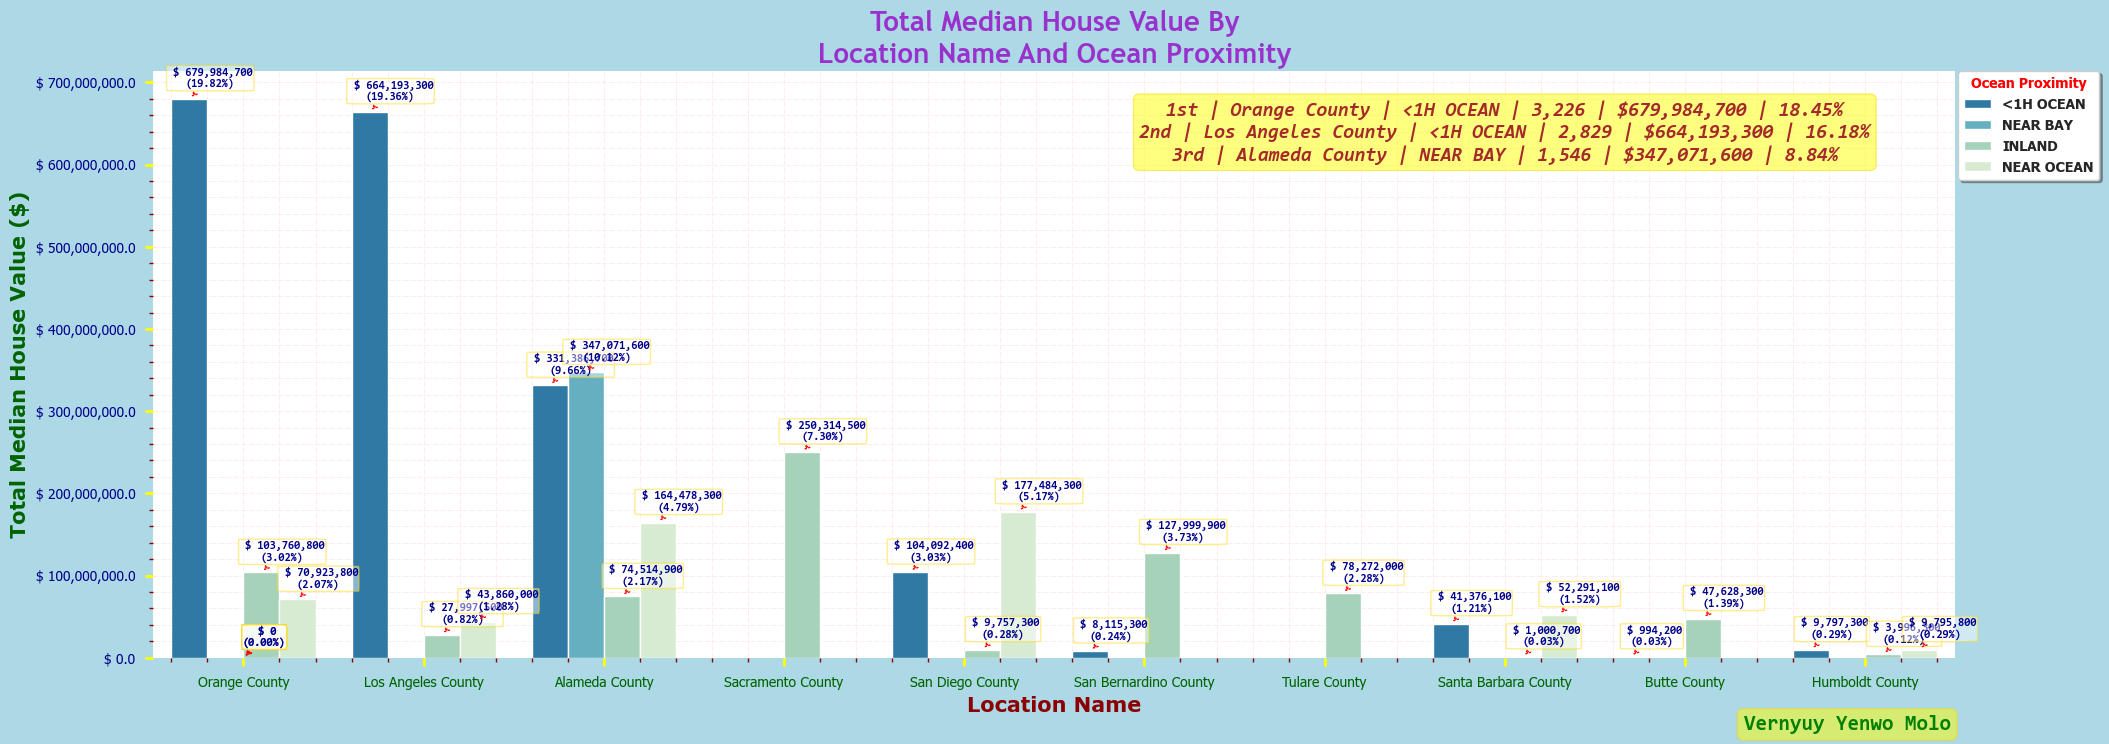

In [237]:
# Barplot - Total Median House Value By Location Name And Ocean Proximity.

# Step 1: Exclude the 'location_name' row by label, not by position before plotting
c_loc_op = c_loc_op.loc[c_loc_op['location_name'].notna()]

#==#

# Step 2 : Plot barplot
g = sns.catplot(data=c_loc_op,x='location_name',y='sum',hue='ocean_proximity',row=None,col=None,kind='bar',estimator='sum',errorbar=('ci', 95),n_boot=1000,
seed=None,units=None,weights=None,order=None,hue_order=None,row_order=None,col_order=None,col_wrap=None,height=5,aspect=2,log_scale=None,native_scale=False,formatter=None,
orient=None,color=None,palette='GnBu_r',hue_norm=None,legend='full',legend_out=False,sharex=False,sharey=False,margin_titles=False,facet_kws=None,edgecolor=None,
saturation=0.75,fill=True,width=0.8,dodge='auto',gap=0,capsize=0,err_kws=None,)

#==#

# Step 3: Set figure size
g.figure.set_size_inches(20, 7.5)
# g.figure.set_size_inches(15, 7.5)

#==#
 
# Step 4: Access the underlying axes
axes = g.axes.flatten()

#==#

# Step 5 : Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
for ax in g.axes.flat:
    ax.set_title('Total Median House Value By\n' + 'Location Name And Ocean Proximity', loc='center', fontdict=title_font)
    ax.set_xlabel('Location Name', loc='center', fontdict=x_label_font)
    ax.set_ylabel('Total Median House Value ($)', loc='center', fontdict=y_label_font)
    # ax.xaxis.set_major_formatter(StrMethodFormatter('£ {x:,}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
    ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
    ax.minorticks_on()
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_visible(False)
    ax.set_facecolor('white')
    ax.grid(which='both',linestyle='dashdot', color='mistyrose',linewidth=0.5)
    # ax.autoscale()
    # ax.axis('equal')
    # ax.set_xlim(left=0)
    # ax.set_ylim(bottom=0)
    # ax.set_ylim(0,355000)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_yscale('linear')  # Try removing log scale

title_props=dict(family='tahoma', style='normal', weight='bold', size='small')
legend_props=dict(family='tahoma', style='normal', weight='bold', size='small')
# sns.move_legend(g,"upper left", bbox_to_anchor=(0.99, 0.96), borderaxespad=0, title='Ocean Proximity', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend = ax.legend(loc='best', bbox_to_anchor=(1.08, 1), borderaxespad=0, title='Ocean Proximity', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend.get_title().set_color("red")

#==#

# Step 6: Annotate values and percentages in arrow & bbox circle format - £/%.

# Annotation format properties
arrow = dict(arrowstyle="->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3,rad=0')
box=dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Annotate the bars
ax = g.facet_axis(0, 0)  # Since we don't have row or col, it's always (0, 0)
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2 
    y = p.get_height()
    ax.annotate(f' $ {y:,.0f}\n({y/ c_loc_op["sum"].sum():.2%})', (x, y), xytext=(15, 15),
                ha='center', va='center', fontfamily='consolas', fontstyle='normal', fontsize=8, fontweight='bold', color='darkblue', rotation=0,
                textcoords='offset points', arrowprops=arrow, bbox=box)

# #==#

# Step 7: Add signature to figure in bbox round format
ax.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ax.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

# #==#

# Step 8: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean = c_loc_op.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by sum in descending order and select top 3
top_sums = df_clean.sort_values(by='sum', ascending=False).head(3) # count

# Display the top 3 highest sums
for i, row in top_sums.iterrows():
    rank = ['1st', '2nd', '3rd'][top_sums.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['ocean_proximity']}, {row['count']:,.0f}, ${row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['ocean_proximity']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_sums.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
ax.annotate(annotation_text,xy=(7, 600000000),xytext=(7, 600000000),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))

# #==#

# # Step 9: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Total_Median_House_Value_By_Location_Name_And_Ocean_Proximity_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# #==#

# Step 10: Display plot
plt.show()

**`Barplot - Property Count By Location & Ocean Proximity (Plotly)`**.

In [238]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.bar(
    c_loc_op,
    x="location_name",
    y="sum",
    color="ocean_proximity", 
    barmode="group",          # "group or "stack" for stacked bars
    text="count",             #  "count", "median", "sum", "proportion"  

    # Fomat hover_data values
    hover_data={
        "Cluster": True,             # no format change
        "count": ":,.0f",            # ✅ formatted as \1,234
        "mean": ":$,.0f",            # ✅ formatted as \$1,234
        "median": ":$,.0f",          # ✅ formatted as \$1,234
        "proportion": ":.2%",        # ✅ formatted as 15.00%
        "sum": ":$,.0f",             # ✅ formatted as \$1,234
        # "Risk": True,                # no format change
        # "Return":  True,             # no format change 
    },
    color_discrete_map={
        "<1H OCEAN": "turquoise",   
        "NEAR BAY": "orange",     
        "INLAND": "green",       
        "NEAR OCEAN": "lightblue",
    },
)

fig.update_traces(
    texttemplate="%{text:,.0f}",       # ✅ Formats 1000 → 1,000
    # texttemplate="%{text:$,.0f}",    # ✅ Formats $1000 → $1,000
    # textposition="inside",           #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    insidetextanchor="end",            # 'end', 'middle', 'start'
    textangle=-90,
    textfont=dict(family="Tahoma", size=14, color="black"),
    # selector=dict(mode="text"), # textposition="top centre"
)

fig.update_layout(
      title={
        "text": "<b><u>Property Count By Location & Ocean Proximity</u></b>" # <b> bold, <i> italic, <u> underline, <br> start new line, <sup> open superscript, </>close, 
        "<br><sup>(Bar labels represent property count per ocean proximity)</sup>", 
        "x": 0.5,              # centers the title
        "xanchor": "center", "font": {"family": "tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",                       # bold x label
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Ocean Proximity</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        # bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("Barplot.jpeg")
# fig.write_image("Barplot.svg")
# fig.write_image("Barplot.pdf")
# fig.write_html("Barplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

**`Scatterplot - Property Count By Location & Ocean Proximity (Plotly)`**.

In [239]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.scatter(
    c_loc_op,
    x="location_name",           # Location on X-axis
    y="sum",                      # Total Median House Value on Y-axis
    color="ocean_proximity",      # Color by ocean proximity
    symbol="ocean_proximity",     # Different shape per ocean proximity
    size="count",                   # Bubble size = coiunt of properties
    text="count",                   # Show count labels on points

    # Fomat hover_data values
    hover_data={
        "Cluster": True,       # no format change
        "count": ":,.0f",      # ✅ formatted as \1,234
        "mean": ":$,.0f",      # ✅ formatted as \$1,234
        "median": ":$,.0f",    # ✅ formatted as \$1,234
        "sum": ":$,.0f",       # ✅ formatted as \$1,234
        "proportion": ":.2%",  # ✅ formatted as 15.00% 
    },
    color_discrete_map={
        "<1H OCEAN": "turquoise",    
        "NEAR BAY": "orange",        
        "INLAND": "green",           
        "NEAR OCEAN": "lightblue",
    },
)
fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1, color="mistyrose")  # Marker border
    ),
    texttemplate="%{text:,.0f}",       # ✅ Formats 1000 → 1,000
    textposition="top center",         #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    textfont=dict(family="Tahoma", size=10, color="black"),
    selector=dict(mode="markers+text"),
)

fig.update_layout(
    title={
        "text": "<b><u>Property Count By Location & Ocean Proximity</u></b>"
        "<br><sup>(Scatterplot markers represent property count per ocean proximity)</sup>", 
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Ocean Proximity</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        # bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("scatterplot.jpeg")
# fig.write_image("scatterplot.svg")
# fig.write_image("scatterplot.pdf")
# fig.write_html("scatterplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

**`Scatterplot - Total Median House Value ($) By Location & Ocean Proximity (Plotly)`**.

In [240]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.scatter(
    c_loc_op,
    x="location_name",           # Location on X-axis
    y="sum",                      # Total Median House Value on Y-axis
    color="ocean_proximity",      # Color by ocean proximity
    symbol="ocean_proximity",     # Different shape per ocean proximity
    size="sum",                   # Bubble size = sum of properties
    text="sum",                   # Show sum labels on points

    # Fomat hover_data values
    hover_data={
        "Cluster": True,       # no format change
        "count": ":,.0f",      # ✅ formatted as \1,234
        "mean": ":$,.0f",      # ✅ formatted as \$1,234
        "median": ":$,.0f",    # ✅ formatted as \$1,234
        "sum": ":$,.0f",       # ✅ formatted as \$1,234
        "proportion": ":.2%",  # ✅ formatted as 15.00% 
    },
    color_discrete_map={
        "<1H OCEAN": "turquoise",    
        "NEAR BAY": "orange",        
        "INLAND": "green",           
        "NEAR OCEAN": "lightblue",
    },
)
fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1, color="mistyrose")  # Marker border
    ),
    texttemplate="%{text:$,.0f}",       # ✅ Formats 1000 → 1,000
    textposition="top center",          #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    textfont=dict(family="Tahoma", size=10, color="black"),
    selector=dict(mode="markers+text"),
)

fig.update_layout(
    title={
        "text": "<b><u>Total Median House Value ($) By Location & Ocean Proximity</u></b>"
        "<br><sup>(Scatterplot markers represent property value per ocean proximity)</sup>", 
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Ocean Proximity</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        # bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("scatterplot.jpeg")
# fig.write_image("scatterplot.svg")
# fig.write_image("scatterplot.pdf")
# fig.write_html("scatterplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

##### `🏡 California Housing: Housing Strategy And Median House Value Per Geographic Cluster`.

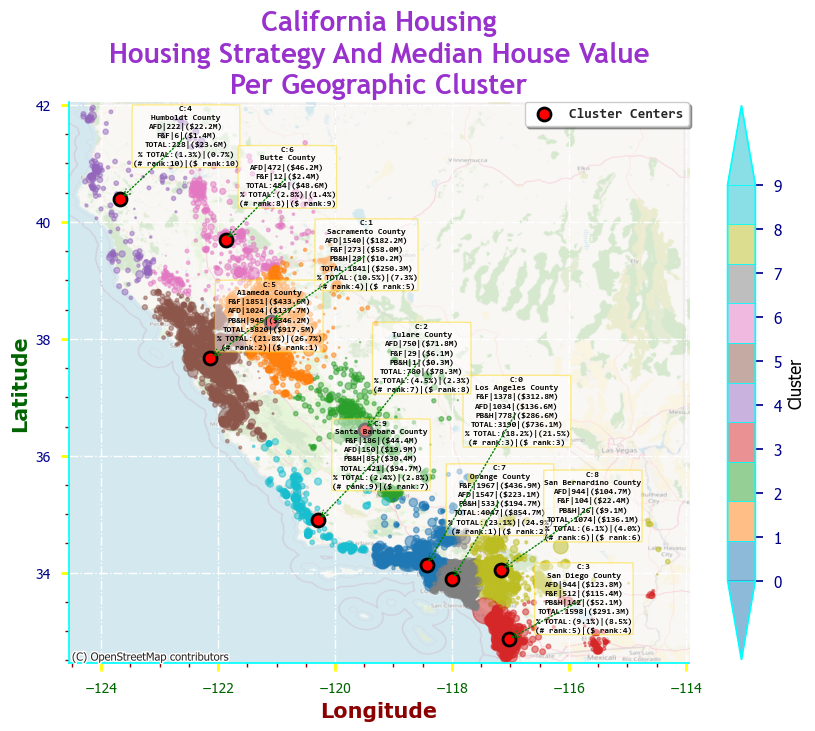

In [241]:
# Geographic cluster visualisation
# - KMeans clustering on lat/lon
# - Median house value & income per cluster
# - OpenStreetMap (via contextily) basemap overlay

#==#

# Fit KMeans on location
kmeans = KMeans(n_clusters=10, random_state=42)
final["Cluster"] = kmeans.fit_predict(final[["latitude", "longitude"]])
median_house_value = final.groupby("Cluster")["median_house_value"].median()
income_per_person = final.groupby("Cluster")["income_per_person"].median()
median_income = final.groupby("Cluster")["median_income"].median()

#==#

# MAP 1 - Median House Value, Median Income and Median Income Per Person Per Geographic Cluster

# Pre-compute median house value sum per Cluster
mhv_cluster_medians = final.groupby("Cluster")["median_house_value"].median()

# Rank across all median house value clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mipp_cluster_medians = final.groupby("Cluster")["income_per_person"].median()

# Rank across all median income per person clusters (highest value = rank 1)
mipp_cluster_ranks = mipp_cluster_medians.rank(ascending=False, method='min').astype(int)

# Pre-compute median income per Cluster
mi_cluster_medians = final.groupby("Cluster")["median_income"].median()

# Rank across all ocean_proximity clusters (highest value = rank 1)
mi_cluster_ranks = mi_cluster_medians.rank(ascending=False, method='min').astype(int)

#==#

# MAP 2 - Ocean Proximity and Median House Value Per Geographic Cluster

# Calculate grand totals
grand_total_count = final['ocean_proximity'].value_counts().sum()
grand_total_value = final['median_house_value'].sum()

# Show all ocean proximity, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
ocean_proximity = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{k}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['ocean_proximity'].value_counts().items()])
        + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['ocean_proximity'].value_counts().sum()/grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all mhv clusters (highest value = rank 1)
mhv_cluster_ranks = mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute total ocean proximity count per Cluster
op_cluster_totals = final.groupby("Cluster")["ocean_proximity"].count()

# Rank across all ocean_proximity clusters (highest value = rank 1)
op_cluster_ranks = op_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# MAP 3 - Housing Strategy and Median House Value Per Geographic Cluster

# Shortened version for cleaner map
strategy_short = {
    'Premium Buy & Hold': 'PB&H',
    'Volume Investment (Fix & Flip)': 'F&F',
    'Affordable Development': 'AFD'
}

# Map shortened names
final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# Calculate grand totals
bs_grand_total_count = final['Best Strategy'].value_counts().sum()
bs_grand_total_value = final['median_house_value'].sum()

# Get all strategies per cluster with shortened names, counts, $ values, count total, median house value total, count total percentage and median house value total percentage
best_strategy = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['Best Strategy'].value_counts().items()])
        + f"\nTOTAL:{x['Best Strategy'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)"
        + f"\n% TOTAL:({(x['Best Strategy'].value_counts().sum()/bs_grand_total_count)*100:.1f}%)|({(x['median_house_value'].sum()/bs_grand_total_value)*100:.1f}%)",
    include_groups=False)

# Pre-compute total median house value sum per Cluster
bs_mhv_cluster_totals = final.groupby("Cluster")["median_house_value"].sum()

# Rank across all median house value clusters (highest value = rank 1)
bs_mhv_cluster_ranks = bs_mhv_cluster_totals.rank(ascending=False, method='min').astype(int)

# Pre-compute best strategy count per Cluster
bs_cluster_totals = final.groupby("Cluster")["Best Strategy Short"].count()

# Rank across all best strategy clusters (highest value = rank 1)
bs_cluster_ranks = bs_cluster_totals.rank(ascending=False, method='min').astype(int)

#==#

# # MAP 2 - CODE 2
# # Show all ocean proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{[k]}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False)

#==#

# # MAP 2 - CODE 3
# # Show all ocean_proximity, counts, $ values, count total and median house value total
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x['ocean_proximity'].value_counts().items()])
#                          + f"\nCNT:{x['ocean_proximity'].value_counts().sum():,.0f}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.2f}M)", include_groups=False)

#==#

# # MAP 2 - CODE 4
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|{(v/x['ocean_proximity'].value_counts().sum())*100:.1f}%|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)|{(x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum())*100:.1f}%" 
#         for k, v in x['ocean_proximity'].value_counts().items()])
#         + f"\nTOTAL:|{x['ocean_proximity'].value_counts().sum()}|100%|(${x['median_house_value'].sum()/1e6:,.1f}M)|100%",
#     include_groups=False)

# print(ocean_proximity)

#==#

# # MAP 2 - CODE 5
# # Show all ocean proximity, counts, $ values, count total, median house value total with percentages
# ocean_proximity = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{k}|{v}|({v/len(x)*100:.1f}%)|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M ({x[x['ocean_proximity']==k]['median_house_value'].sum()/x['median_house_value'].sum()*100:.1f}%)" 
#         for k, v in x['ocean_proximity'].value_counts().items()
#     ]) + f"\nTOTAL:{len(x)}|(${x['median_house_value'].sum()/1e6:,.1f}M)",
#     include_groups=False
# )

# print(ocean_proximity)

#==#

# # MAP 3 - CODE 1
# # Get Best Strategy per Cluster (most common strategy in each cluster)
# best_strategy = final.groupby("Cluster")["Best Strategy"].agg(lambda x: x.value_counts().index[0])

#==#

# # MAP 3 - CODE 2
# # Get all strategies per cluster with their counts
# best_strategy = final.groupby("Cluster")["Best Strategy"].apply(
#     lambda x: '\n'.join([f"{k}({v})" for k, v in x.value_counts().items()])
# )

#==#

# # MAP 3 - CODE 3
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}" for k, v in x.value_counts().items()]), include_groups=False)

#==#

# # MAP 3 - CODE 4
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names and count total
# best_strategy = final.groupby("Cluster")["Best Strategy Short"].apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x.value_counts().items()])
#                          + f"\nCNT:({x.value_counts().sum()})", include_groups=False)

#==#

# # MAP 3 - CODE 5
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([f"{k}:{v}"
#                          for k, v in x["Best Strategy Short"].value_counts().items()])
#                          + f"\nCNT:{x["Best Strategy Short"].value_counts().sum()}"
#                          + f"\nMHVSUM:(${x['median_house_value'].sum()/1000:,.0f}M)", include_groups=False # .sum()/1e6:,.0f}M)"
# )

#==#

# # MAP 3 - CODE 6
# # Shortened version for cleaner map
# strategy_short = {
#     'Premium Buy & Hold': 'PB&H',
#     'Volume Investment (Fix & Flip)': 'F&F',
#     'Affordable Development': 'AFD'
# }

# # Map shortened names
# final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# # Get all strategies per cluster with shortened names, counts, $ values, count total and median house value total
# best_strategy = final.groupby("Cluster").apply(
#     lambda x: '\n'.join([
#         f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
#         for k, v in x['Best Strategy'].value_counts().items()
#     ]) + 
#     f"\nCNT:{x['Best Strategy'].value_counts().sum()}" +
#     f"\nMHVSUM:(${x['median_house_value'].sum()/1e6:,.1f}M)", include_groups=False)

#==#

# Plot scatterplot and capture the returned axes
fig, gc3 = plt.subplots(ncols=1, nrows=1, figsize=(10,8), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# Plot
# plt.figure(figsize=(10, 8))
scatter = gc3.scatter(final["longitude"], final["latitude"],
                      c=final["Cluster"], cmap="tab10", # c expects a color-mappable array, while color accepts a simple color string like "red".
                      s=final["population"]/100, alpha=0.5) # Dividing by 100 scales population (e.g 5000, 10000) down to a reasonable dot size range.
plt.scatter(kmeans.cluster_centers_[:, 1], 
            kmeans.cluster_centers_[:, 0],
            c="red", ec='black', marker=".", s=(350), 
            linewidths=2, label="Cluster Centers") 

#==============================================================#

# # OLD BUILD - DO NOT USE!!
# # Import Geolocator
# from geopy.geocoders import Nominatim

# # Initialise Geolocator
# geolocator = Nominatim(user_agent="vym1")

# def get_location_name(lat, lon):
#     location = geolocator.reverse(f"{lat}, {lon}")
#     return location.raw['address'].get('city') or \
#            location.raw['address'].get('town') or \
#            location.raw['address'].get('county')


# # Hardcoded location names from previous map
# location_names = {
#     0: "Los Angeles",
#     1: "Newark",
#     2: "Ventura County",
#     3: "Fresno",
#     4: "Sacramento County",
#     5: "Santee",
#     6: "Trinity County",
#     7: "Sonoma County",
#     8: "Chino",
#     9: "Arroyo Grande"
# }

# def get_location_name(lat, lon):
#     return location_names.get(i, f"({lat:.1f}, {lon:.1f})")

#==============================================================#

from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="vym1")

def get_location_name(lat, lon):
    try:
        time.sleep(1)  # ✅ Respect Nominatim rate limit (1 req/sec)
        location = geolocator.reverse(
            f"{lat}, {lon}",
            exactly_one=True,
            language="en",
            zoom=8  # ✅ Key fix: zoom=8 = county/region level, not street level
        )
        if location is None:
            return f"({lat:.1f}, {lon:.1f})"
        
        address = location.raw['address']
        
        # ✅ Walk through from most to least specific regional name
        return (
            address.get('city')        or  # e.g. Los Angeles
            address.get('town')        or  # e.g. smaller towns
            address.get('village')     or  # e.g. rural areas
            address.get('suburb')      or  # e.g. city districts
            address.get('county')      or  # e.g. Trinity County
            address.get('state_district') or
            address.get('state')       or  # fallback to state
            f"({lat:.1f}, {lon:.1f})"     # final fallback
        )
    except Exception as e:
        print(f"Geocoding failed for ({lat}, {lon}): {e}")
        return f"({lat:.1f}, {lon:.1f})"

#==#

# # Annotation format properties
# arrow = dict(arrowstyle="]->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
# box = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# # Annotate cluster centers with cluster number
# for i, center in enumerate(kmeans.cluster_centers_):
#     plt.annotate(f"C:{i}",
#                  xy=(center[1], center[0]), xytext=(-35, -15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with cluster number, location and ocean_proximity
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc3.annotate(f"C:{i}\n{location_name}\n{ocean_proximity[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='green', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
    
# # Annotate cluster centers with cluster number, location, median_house_value, income_per_person and median_income
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc3.annotate(f"C:{i}\n{location_name}\nMHV:(${median_house_value[i]/1000:,.2f}k)\nMIPP:(${income_per_person[i]/1000:,.2f}k)\nMI:(${median_income[i]/1000:,.2f}k)",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='green', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)

# # Annotate cluster centers with cluster number, location and best strategy
# for i, center in enumerate(kmeans.cluster_centers_):
#     location_name = get_location_name(center[0], center[1])
#     gc3.annotate(f"C:{i}\n{location_name}\n{best_strategy[i]}",
#                  xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points", ha='center', va='center',
#                  color='darkblue', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
    
# # Annotate cluster centers with longitiude and latitude
# for i, center in enumerate(kmeans.cluster_centers_):
#     gc3.annotate(f"\nLat:({center[0]:,.1f})\nLong:({center[1]:,.1f})",
#                  xy=(center[1], center[0]), xytext=(-25, -25), textcoords="offset points", ha='center', va='center',
#                  color='red', fontsize=6, fontweight="bold", fontfamily='consolas', fontstyle='normal', rotation=0, arrowprops=arrow,bbox=box)
                 
#==#

# Annotate cluster centers with cluster number, location name, best strategy count, best strategy MHV, BS count rank, BS MHV $ rank, longitude & latitude 

# Annotation format properties
arrow_3 = dict(arrowstyle="->", color='green', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3, rad=0')
box_3 = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Import adjust_text library
from adjustText import adjust_text

# Pre-build location names BEFORE the loop (avoids repeated API calls)
location_names = {
    i: get_location_name(center[0], center[1])
    for i, center in enumerate(kmeans.cluster_centers_)
}

# Define empty list
texts = []

for i, center in enumerate(kmeans.cluster_centers_):
    location_name = get_location_name(center[0], center[1])
    texts.append(
        gc3.text(
            center[1] + 0.5,  # Cluster longitude, + 0.5 - Move text East  ➡️,  -0.5 - Move text West  ⬅️
            center[0] + 0.4,  # Cluster latitude, + 0.5 - Move text North ⬆️, -0.5  - Move text South ⬇️
            f"C:{i}\n{location_name}\n{best_strategy[i]}\n(# rank:{bs_cluster_ranks[i]})|($ rank:{bs_mhv_cluster_ranks[i]})",
            color='black', fontsize=6, fontweight="bold",
            fontfamily='consolas', fontstyle='normal', rotation=0,
            bbox=box_3
        )
    )

# Auto adjust text positions first
adjust_text(texts, ax=gc3)

# Then draw YOUR arrows from adjusted text positions to cluster centers
for i, (text, center) in enumerate(zip(texts, kmeans.cluster_centers_)):
    # Get adjusted text position
    text_x, text_y = text.get_position()
    
    # Draw arrow from text box to cluster center
    gc3.annotate("",
                xy=(center[1], center[0]),        # ✅ Arrow HEAD at cluster center
                xytext=(text_x, text_y),           # ✅ Arrow TAIL at text box
                arrowprops=arrow_3,                  # ✅ Your original arrow style
                xycoords='data',
                textcoords='data')

#==============================================================#

# OLD PLOT
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("California Housing - Location Clusters")
# plt.legend()
# plt.show()

#==============================================================#

# Format colobar value
fmt = lambda x,pos: '{:,.0f}'.format(x)

# Keyword arguements for colorbar appearance
cbar_kws = {"orientation":"vertical", "shrink":0.9, 'extend':'both', 'extendfrac':0.2, "drawedges":True, 'label':'Cluster', 'spacing':'uniform', 'format':fmt}

# Plot colobar
plt.colorbar(scatter, ax=gc3, **cbar_kws) # label='Cluster'

# Set plot legend properties
title_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = gc3.legend(loc='best',bbox_to_anchor=(1, 1),borderaxespad=0,title='',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

# Set plot axes properties
gc3.set_title('California Housing'+'\nHousing Strategy And Median House Value'+'\nPer Geographic Cluster',loc='center', fontdict=title_font)
gc3.set_xlabel('Longitude', loc='center', fontdict=x_label_font) # Independent Variable
gc3.set_ylabel('Latitude', loc='center', fontdict=y_label_font) # Dependent Variable
# gc3.grid(linestyle='dashdot', color='pink', linewidth=0.5)
# gc3.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc3.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
# gc3.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gc3.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
gc3.minorticks_on()
gc3.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gc3.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gc3.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gc3.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# gc3.autoscale()
# gc3.axis('equal')
# gc3.set_xlim(left=0)
# gc3.set_ylim(bottom=0)
# gc3.set_xscale('log')
# gc3.set_yscale('log')
# gc3.set_yscale('linear')  # Try removing log scale

#==#

# Add map tile as background
from pathlib import Path
import contextily as ctx
ctx.add_basemap(gc3, 
                crs="EPSG:4326",  # lat/lon coordinate system
                source=ctx.providers.OpenStreetMap.Mapnik,alpha=0.5)

gc3.set_xlim(-124.55, -113.95)
gc3.set_ylim(32.45, 42.05)

#==#

# filename = "Map.png"
# filepath = Path("C:/Users/tailb/Downloads/Map.png")
# california_img = plt.imread(filepath)
# axis = -124.55, -113.95, 32.45, 42.05
# plt.imshow(california_img, extent=axis, alpha=0.5)  # background first
# plt.axis(axis)

#==#

# my_path = r"\Users\tailb\Downloads"
# plt.savefig(my_path + '/Map3.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Housing_Strategy_And_MHV_Per_Geographic_Cluster_Geospatial_KMeans_Cluster_Bubble_Map.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Display plot
plt.show()

**`🗺️ Key Insights`**:
- --
 - **`Map 3 — Housing Strategy and Median House Value Per Geographic Cluster`**.
- -- 
   - **`🏆 Tier 1 (Highest) — Alameda County (C5, \$917.5M | 26.7% | 3,820 count | 21.8%) — 1st by ($) value, 2nd by (#) count`**.

   - **`🥈 Tier 2 (High) — Orange County (C7, \$854.7M | 24.9% | 4,047 count | 23.1%) — 2nd by ($) value and 1st by (#) count`**.

   - **`🥉 Tier 3 (Mid-High) — Los Angeles County (C0, \$736.1M| 21.5% | 3,190 count | 18.2%) — 3rd by ($) value and 3rd by (#) count`**.

   - **`4️⃣ Tier 4 (Mid) — San Diego County (C3, \$291.3M | 8.5% | 1,598 count | 9.1%) and Sacramento County (C1, \$250.3M | 7.3% | 1,841 count | 10.5%)`**.

   - **`5️⃣ Tier 5 (Mid-Low) — San Bernardino County (C8, \$136.1M | 4.0% | 1,074 count | 6.1%) and Santa Barbara County (C9, \$94.7M | 2.8% | 421 count | 2.4%)`**.
   
   - **`6️⃣ Tier 6 (Lowest) — Tulare County (C2, \$78.3M | 2.3% | 780 count | 4.5%), Butte County (C6, \$48.6M | 1.4% | 484 count | 2.8%) and Humboldt County (C4, \$23.6M | 0.7% | 228 count | 1.3%)`**.
- --
**`🎯 General Pattern`**:
- --
  - **`📈 Coastal areas`** = **`higher prices`**.

  - **`📉 Inland/Rural areas`** = **`lower prices`**.

  - **`This confirms that location is a strong predictor of house prices! 🏠`**.
- --

**`Cluster, Location Name And Best Housing Strategy Median House Value Statistics`**.

In [242]:
c_loc_hs = final.groupby(['Cluster', 'location_name', 'Risk', 'Return', 'Best Strategy Short'])['median_house_value']\
    .agg(['count', 'min', 'max', 'mean', 'median', 'sum']).sort_values(by='count', ascending=False).round(2).reset_index()\
        .assign(proportion=lambda x: x["count"] / x["count"].sum())
#c_loc_hs['avg_$_per_prop'] = (c_loc_hs['sum'] / c_loc_hs['count']).round(2)
c_loc_hs['count_rank'] = c_loc_hs['count'].rank(ascending=False)
c_loc_hs['median_rank'] = c_loc_hs['median'].rank(ascending=False) 
c_loc_hs['sum_rank'] = c_loc_hs['sum'].rank(ascending=False) 
c_loc_hs

# # Styled - Not for plotting!!
# c_loc_hs = final.groupby(['Cluster', 'location_name', 'Risk', 'Return', 'Best Strategy Short'])['median_house_value'].agg(['count', '', 'max', 'mean', 'median', 'sum'])\
#     .sort_values(by='sum', ascending=False).reset_index()\
#         .assign(proportion=lambda x: x["sum"] / x["sum"].sum()).style.format({'count':'{:,.0f}', 'median':'${:,.0f}', 'sum':'${:,.0f} M', 'proportion':'{:.2%}'})
# c_loc_hs

#==#

# c_loc_hs = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())
# )
# c_loc_hs

# # Styled - Not for plotting!!
# c_loc_hs = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())\
# .style.format({"count": "{:,.0f}", "proportion": "{:.2%}"})
# )
# c_loc_hs

,Cluster,location_name,Risk,Return,Best Strategy Short,count,min,max,mean,median,sum,proportion,count_rank,median_rank,sum_rank
0,7,Orange County,Low-Medium,Medium,F&F,1967,175700.0,296700.0,222106.30,217600.0,436883100.0,0.112509,1.0,14.0,1.0
1,5,Alameda County,Low-Medium,Medium,F&F,1851,175700.0,296800.0,234240.57,235200.0,433579300.0,0.105874,2.0,10.0,2.0
2,7,Orange County,Medium,Low-Medium,AFD,1547,67500.0,175400.0,144217.65,151400.0,223104700.0,0.088486,3.0,19.0,6.0
3,1,Sacramento County,Medium,Low-Medium,AFD,1540,66300.0,175300.0,118284.48,117100.0,182158100.0,0.088086,4.0,24.0,8.0
4,0,Los Angeles County,Low-Medium,Medium,F&F,1378,175700.0,296800.0,226989.55,225000.0,312791600.0,0.078819,5.0,11.0,4.0
5,0,Los Angeles County,Medium,Low-Medium,AFD,1034,67500.0,175600.0,132155.51,136700.0,136648800.0,0.059143,6.0,21.0,10.0
6,5,Alameda County,Medium,Low-Medium,AFD,1024,67500.0,175500.0,134458.30,139800.0,137685300.0,0.058571,7.0,20.0,9.0
7,5,Alameda County,Low,High,PB&H,945,296900.0,489600.0,366335.34,353800.0,346186900.0,0.054053,8.0,3.0,3.0
8,3,San Diego County,Medium,Low-Medium,AFD,944,66400.0,175600.0,131183.90,135650.0,123837600.0,0.053995,9.5,23.0,11.0
9,8,San Bernardino County,Medium,Low-Medium,AFD,944,66300.0,174800.0,110889.83,109950.0,104680000.0,0.053995,9.5,25.0,13.0


**`Barplot - Property Count By Location And Best Housing Strategy`**.

'Orange County' - 1st, F&F, 1,967, $436,883,100, 11.25%
'Alameda County' - 2nd, F&F, 1,851, $433,579,300, 10.59%
'Orange County' - 3rd, AFD, 1,547, $223,104,700, 8.85%


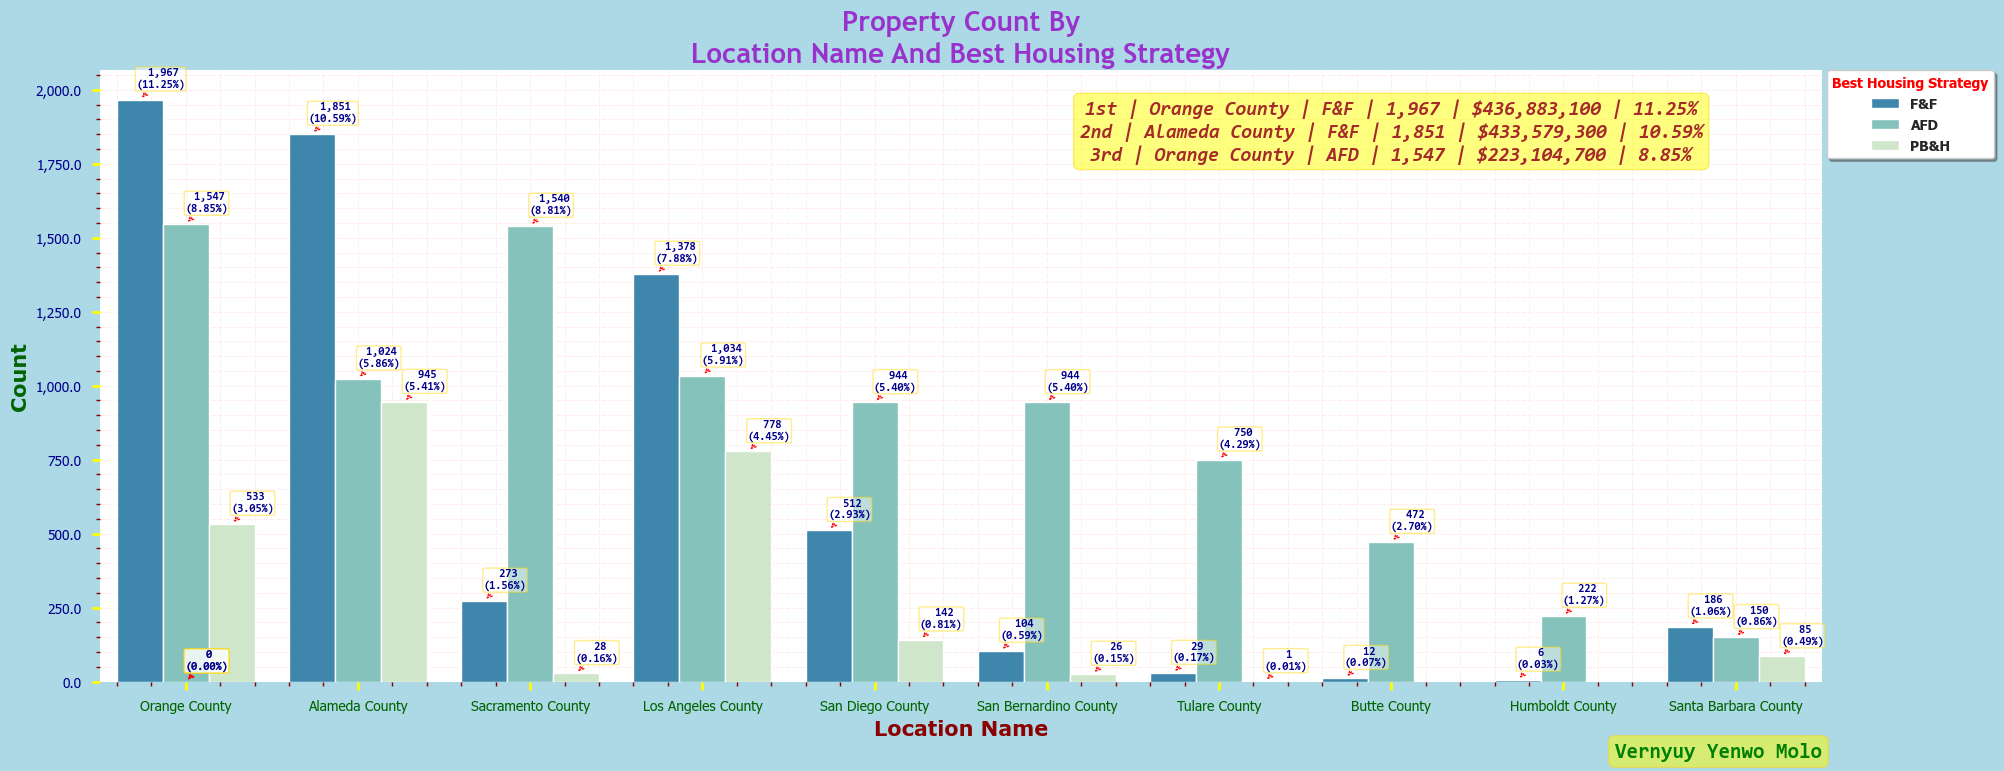

In [243]:
# Barplot - Property Count By Location And Best Housing Strategy.

# Step 1: Exclude the 'location_name' row by label, not by position before plotting
c_loc_hs = c_loc_hs.loc[c_loc_hs['location_name'].notna()]

#==#

# Step 2 : Plot barplot
g = sns.catplot(data=c_loc_hs,x='location_name',y='count',hue='Best Strategy Short',row=None,col=None,kind='bar',estimator='sum',errorbar=('ci', 95),n_boot=1000,
seed=None,units=None,weights=None,order=None,hue_order=None,row_order=None,col_order=None,col_wrap=None,height=5,aspect=2,log_scale=None,native_scale=False,formatter=None,
orient=None,color=None,palette='GnBu_r',hue_norm=None,legend='full',legend_out=False,sharex=False,sharey=False,margin_titles=False,facet_kws=None,edgecolor=None,
saturation=0.75,fill=True,width=0.8,dodge='auto',gap=0,capsize=0,err_kws=None,)

#==#

# Step 3: Set figure size
g.figure.set_size_inches(20, 7.5)
# g.figure.set_size_inches(15, 7.5)

#==#
 
# Step 4: Access the underlying axes
axes = g.axes.flatten()

#==#

# Step 5 : Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
for ax in g.axes.flat:
    ax.set_title('Property Count By\n' + 'Location Name And Best Housing Strategy', loc='center', fontdict=title_font)
    ax.set_xlabel('Location Name', loc='center', fontdict=x_label_font)
    ax.set_ylabel('Count', loc='center', fontdict=y_label_font)
    # ax.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
    ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
    ax.minorticks_on()
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_visible(False)
    ax.set_facecolor('white')
    ax.grid(which='both',linestyle='dashdot', color='mistyrose',linewidth=0.5)
    # ax.autoscale()
    # ax.axis('equal')
    # ax.set_xlim(left=0)
    # ax.set_ylim(bottom=0)
    # ax.set_ylim(0,355000)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_yscale('linear')  # Try removing log scale

title_props=dict(family='tahoma', style='normal', weight='bold', size='small')
legend_props=dict(family='tahoma', style='normal', weight='bold', size='small')
# sns.move_legend(g,"upper left", bbox_to_anchor=(0.99, 0.96), borderaxespad=0, title='Best Housing Strategy', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend = ax.legend(loc='best', bbox_to_anchor=(1.10, 1), borderaxespad=0, title='Best Housing Strategy', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend.get_title().set_color("red")

#==#

# Step 6: Annotate values and percentages in arrow & bbox circle format - £/%.

# Annotation format properties
arrow = dict(arrowstyle="->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3,rad=0')
box=dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Annotate the bars
ax = g.facet_axis(0, 0)  # Since we don't have row or col, it's always (0, 0)
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2 
    y = p.get_height()
    ax.annotate(f' {y:,.0f}\n({y/ c_loc_hs["count"].sum():.2%})', (x, y), xytext=(15, 15),
                ha='center', va='center', fontfamily='consolas', fontstyle='normal', fontsize=8, fontweight='bold', color='darkblue', rotation=0,
                textcoords='offset points', arrowprops=arrow, bbox=box)

# #==#

# Step 7: Add signature to figure in bbox round format
ax.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ax.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

# #==#

# Step 8: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean = c_loc_hs.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by count in descending order and select top 3
top_counts = df_clean.sort_values(by='count', ascending=False).head(3) # count

# Display the top 3 highest counts
for i, row in top_counts.iterrows():
    rank = ['1st', '2nd', '3rd'][top_counts.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['Best Strategy Short']}, {row['count']:,.0f}, ${row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['Best Strategy Short']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_counts.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
ax.annotate(annotation_text,xy=(7, 1750),xytext=(7, 1750),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))

# #==#

# # Step 9: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Property_Count_By_Location_Name_And_Best_Housing_Strategy_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# #==#

# Step 10: Display plot
plt.show()

**`Barplot - Total Median House Value By Location Name And Best Housing Strategy`**.

'Orange County' - 1st, F&F, 1,967, $436,883,100, 11.25%
'Alameda County' - 2nd, F&F, 1,851, $433,579,300, 10.59%
'Alameda County' - 3rd, PB&H, 945, $346,186,900, 5.41%


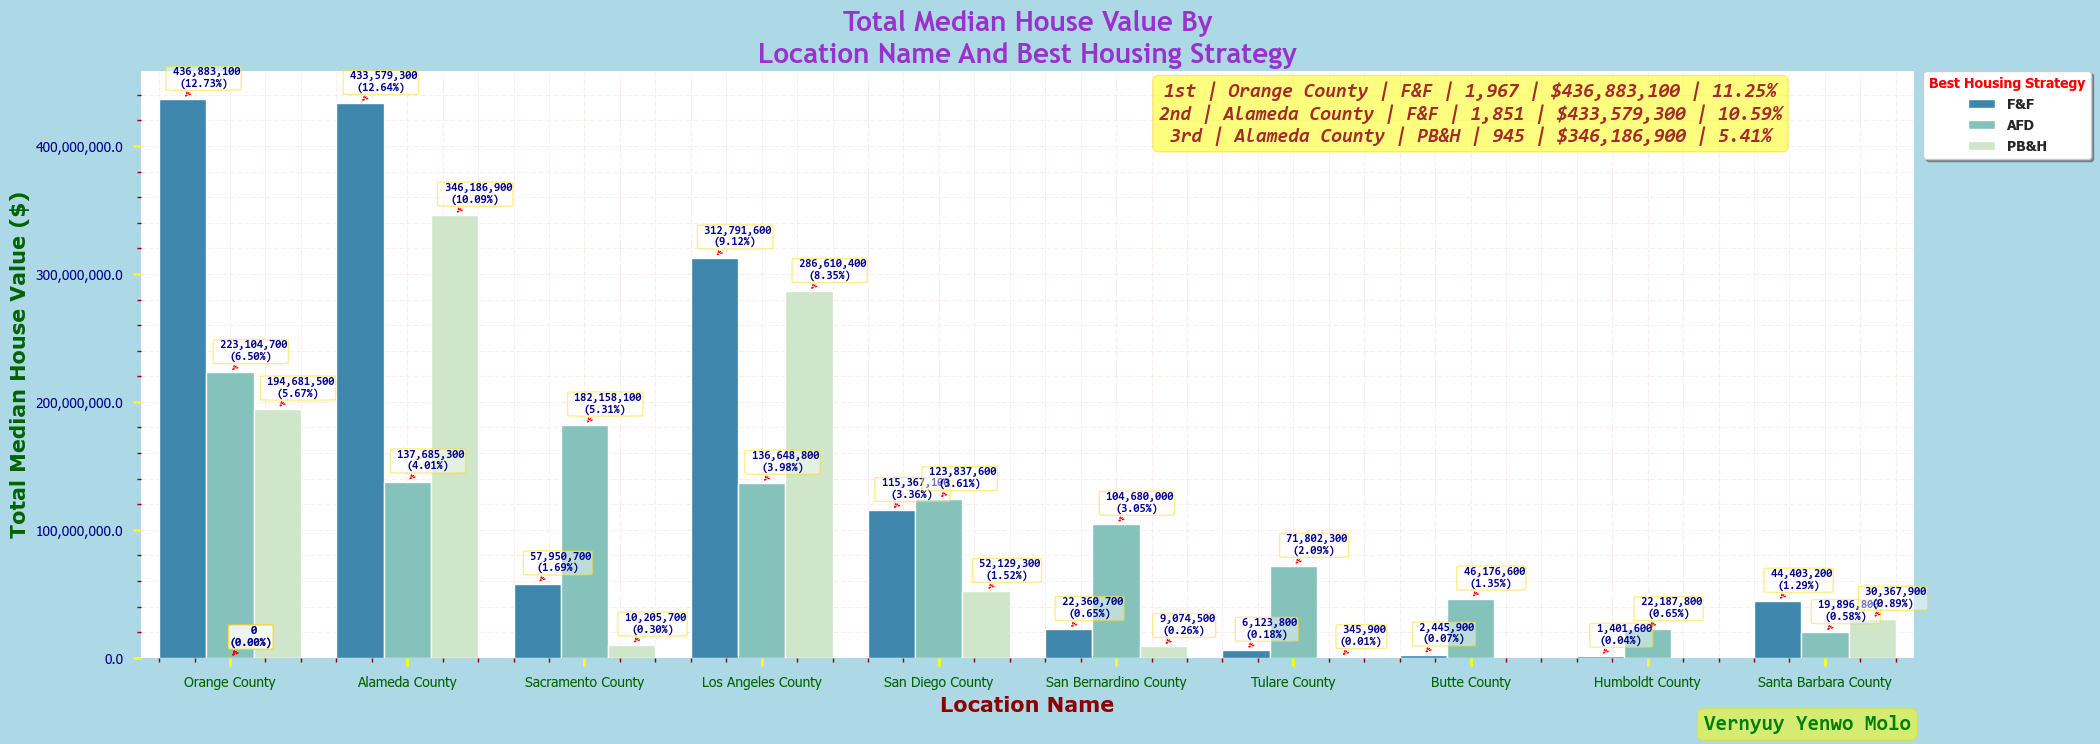

In [244]:
# Barplot - Total Median House Value By Location And Best Housing Strategy.

# Step 1: Exclude the 'location_name' row by label, not by position before plotting
c_loc_hs = c_loc_hs.loc[c_loc_hs['location_name'].notna()]

#==#

# Step 2 : Plot barplot
g = sns.catplot(data=c_loc_hs,x='location_name',y='sum',hue='Best Strategy Short',row=None,col=None,kind='bar',estimator='sum',errorbar=('ci', 95),n_boot=1000,
seed=None,units=None,weights=None,order=None,hue_order=None,row_order=None,col_order=None,col_wrap=None,height=5,aspect=2,log_scale=None,native_scale=False,formatter=None,
orient=None,color=None,palette='GnBu_r',hue_norm=None,legend='full',legend_out=False,sharex=False,sharey=False,margin_titles=False,facet_kws=None,edgecolor=None,
saturation=0.75,fill=True,width=0.8,dodge='auto',gap=0,capsize=0,err_kws=None,)

#==#

# Step 3: Set figure size
g.figure.set_size_inches(20, 7.5)
# g.figure.set_size_inches(15, 7.5)

#==#
 
# Step 4: Access the underlying axes
axes = g.axes.flatten()

#==#

# Step 5 : Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
for ax in g.axes.flat:
    ax.set_title('Total Median House Value By\n' + 'Location Name And Best Housing Strategy', loc='center', fontdict=title_font)
    ax.set_xlabel('Location Name', loc='center', fontdict=x_label_font)
    ax.set_ylabel('Total Median House Value ($)', loc='center', fontdict=y_label_font)
    # ax.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
    ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
    ax.minorticks_on()
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_visible(False)
    ax.set_facecolor('white')
    ax.grid(which='both',linestyle='dashdot', color='mistyrose',linewidth=0.5)
    # ax.autoscale()
    # ax.axis('equal')
    # ax.set_xlim(left=0)
    # ax.set_ylim(bottom=0)
    # ax.set_ylim(0,355000)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_yscale('linear')  # Try removing log scale

title_props=dict(family='tahoma', style='normal', weight='bold', size='small')
legend_props=dict(family='tahoma', style='normal', weight='bold', size='small')
# sns.move_legend(g,"upper left", bbox_to_anchor=(0.99, 0.96), borderaxespad=0, title='Best Housing Strategy', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend = ax.legend(loc='best', bbox_to_anchor=(1.10, 1), borderaxespad=0, title='Best Housing Strategy', title_fontproperties=title_props, prop=legend_props, frameon=True, shadow=True, fancybox=True)
legend.get_title().set_color("red")

#==#

# Step 6: Annotate values and percentages in arrow & bbox circle format - £/%.

# Annotation format properties
arrow = dict(arrowstyle="->", color='red', mutation_aspect=1, linewidth=1, linestyle='dotted', capstyle='round', joinstyle='round', alpha=1, connectionstyle='arc3,rad=0')
box=dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Annotate the bars
ax = g.facet_axis(0, 0)  # Since we don't have row or col, it's always (0, 0)
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2 
    y = p.get_height()
    ax.annotate(f' {y:,.0f}\n({y/ c_loc_hs["sum"].sum():.2%})', (x, y), xytext=(15, 15),
                ha='center', va='center', fontfamily='consolas', fontstyle='normal', fontsize=8, fontweight='bold', color='darkblue', rotation=0,
                textcoords='offset points', arrowprops=arrow, bbox=box)

# #==#

# Step 7: Add signature to figure in bbox round format
ax.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ax.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

# #==#

# Step 8: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean = c_loc_hs.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by sum in descending order and select top 3
top_sums = df_clean.sort_values(by='sum', ascending=False).head(3) # count

# Display the top 3 highest sums
for i, row in top_sums.iterrows():
    rank = ['1st', '2nd', '3rd'][top_sums.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['Best Strategy Short']}, {row['count']:,.0f}, ${row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['Best Strategy Short']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_sums.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
ax.annotate(annotation_text,xy=(7, 400000000),xytext=(7, 400000000),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))

# #==#

# # Step 9: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Total_Median_House_Value_By_Location_Name_And_Best_Housing_Strategy_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# #==#

# Step 10: Display plot
plt.show()

**`Barplot - Property Count By Location & Best Housing Strategy (Plotly)`**.

In [245]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.bar(
    c_loc_hs,
    x="location_name",
    y="sum",
    color="Best Strategy Short", # "Risk", "Return", "Best Strategy Short"
    barmode="group",          # "group or "stack" for stacked bars
    text="count",             #  "count", "median", "sum", "proportion"  
    # hover_data=["Risk", "Return", "mean", "median", "proportion", "Cluster"],
    # Fomat hover_data values
    hover_data={
        "Cluster": True,             # no format change
        "count": ":,.0f",            # ✅ formatted as \1,234
        "mean": ":$,.0f",            # ✅ formatted as \$1,234
        "median": ":$,.0f",          # ✅ formatted as \$1,234
        "proportion": ":.2%",        # ✅ formatted as 15.00%
        "sum": ":$,.0f",             # ✅ formatted as \$1,234
        "Risk": True,                # no format change
        "Return":  True,             # no format change 
    },
    # title="Total Median House Value by Location & Best Housing Strategy",
    color_discrete_map={
        "PB&H": "#2ecc71",   # green — premium
        "F&F":  "#3498db",   # blue — mid
        "AFD":  "#e74c3c"    # red — affordable
    },

    # labels={
    #     "sum": "Total Median House Value ($)</b>",
    #     "location_name": "Location",
    #     "Best Strategy Short": "Housing Strategy"
    # }

)

fig.update_traces(
    texttemplate="%{text:,.0f}",       # ✅ Formats 1000 → 1,000
    # texttemplate="%{text:$,.0f}",    # ✅ Formats $1000 → $1,000
    textposition="outside",            #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    #insidetextanchor="end",            # 'end', 'middle', 'start'
    textangle=0, #-90
    textfont=dict(family="Tahoma", size=11, color="black"),
    # selector=dict(mode="text"), # textposition="top centre"
)

fig.update_layout(
      title={
        "text": "<b><u>Property Count By Location & Best Housing Strategy</u></b>" # <b> bold, <i> italic, <u> underline, <br> start new line, <sup> open superscript, </>close, 
        "<br><sup>(Bar labels represent property count per strategy)</sup>", 
        "x": 0.5,              # centers the title
        "xanchor": "center", "font": {"family": "tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",                       # bold x label
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Housing Strategy</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        # bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("Barplot.jpeg")
# fig.write_image("Barplot.svg")
# fig.write_image("Barplot.pdf")
# fig.write_html("Barplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

**`Scatterplot - Property Count By Location & Best Housing Strategy (Plotly)`**.

In [246]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.scatter(
    c_loc_hs,
    x="location_name",           # Location on X-axis
    y="sum",                      # Total Median House Value on Y-axis
    color="Best Strategy Short",  # Color by strategy
    symbol="Best Strategy Short", # Different shape per strategy
    size="count",                 # Bubble size = count of properties
    text="count",                 # Show count labels on points

    # Fomat hover_data values
    hover_data={
        "Risk": True,             # no format change
        "Return": True,           # no format change
        "mean": ":$,.0f",         # ✅ formatted as \$1,234
        "median": ":$,.0f",       # ✅ formatted as \$1,234
        "proportion": ":.2%",     # ✅ formatted as 15.00%
        "Cluster": True,          # no format change
    },
    color_discrete_map={
        "PB&H": "#2ecc71",   # green — premium
        "F&F":  "#3498db",   # blue — mid
        "AFD":  "#e74c3c"    # red — affordable
    },
)

fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1, color="mistyrose")  # Marker border
    ),
    texttemplate="%{text:,.0f}",       # ✅ Formats 1000 → 1,000
    textposition="top center",         #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    textfont=dict(family="Tahoma", size=10, color="black"),
    selector=dict(mode="markers+text"),
)

fig.update_layout(
    title={
        "text": "<b><u>Property Count By Location & Best Housing Strategy</u></b>"
        "<br><sup>(Scatterplot labels represent property count per strategy)</sup>", 
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Housing Strategy</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        #bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("scatterplot.jpeg")
# fig.write_image("scatterplot.svg")
# fig.write_image("scatterplot.pdf")
# fig.write_html("scatterplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

**`Scatterplot - Total Median House Value ($) By Location & Best Housing Strategy (Plotly)`**.

In [247]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.scatter(
    c_loc_hs,
    x="location_name",           # Location on X-axis
    y="sum",                      # Total Median House Value on Y-axis
    color="Best Strategy Short",  # Color by Housing Strategy
    symbol="Best Strategy Short", # Different shape per strategy
    size="sum",                 # Bubble size = sum of properties
    text="sum",                 # Show sum labels on points

    # Fomat hover_data values
    hover_data={
        "Cluster": True,       # no format change
        "count": ":,.0f",      # ✅ formatted as \1,234
        "mean": ":$,.0f",      # ✅ formatted as \$1,234
        "median": ":$,.0f",    # ✅ formatted as \$1,234
        "sum": ":$,.0f",       # ✅ formatted as \$1,234
        "proportion": ":.2%",  # ✅ formatted as 15.00%
        "Risk": True,          # no format change
        "Return": True,        # no format change    
    },
    color_discrete_map={
        "PB&H": "#2ecc71",   # green — premium
        "F&F":  "#3498db",   # blue — mid
        "AFD":  "#e74c3c"    # red — affordable
    },
)

fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1, color="mistyrose")  # Marker border
    ),
    texttemplate="%{text:$,.0f}",       # ✅ Formats 1000 → 1,000
    textposition="top center",          #  "inside", "top left", "top center", "top right", "middle left", "middle center", "middle right", "bottom left", "bottom center", "bottom right"
    textfont=dict(family="Tahoma", size=10, color="black"),
    selector=dict(mode="markers+text"),
)

fig.update_layout(
    title={
        "text": "<b><u>Total Median House Value ($) By Location & Best Housing Strategy</u></b>"
        "<br><sup>(Scatterplot labels represent property value per strategy)</sup>", 
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,           # ✅ Vertical gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,           # ✅ Horizontal gridlines
        gridcolor="mistyrose",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Housing Strategy</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(             # ✅ Styled hover box
        # bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    )
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("scatterplot.jpeg")
# fig.write_image("scatterplot.svg")
# fig.write_image("scatterplot.pdf")
# fig.write_html("scatterplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

**`Boxplot - Total Median House Value ($) By Location & Best Housing Strategy (Plotly)`**.

In [248]:
# ── Imports ──────────────────────────────────────────────────────────────────
import plotly.express as px
# import plotly.io as pio                                 # 👈 Add this

# pio.renderers.default = "plotly_mimetype+notebook"     # 👈 Add this
# # ─────────────────────────────────────────────────────────────────────────────

fig = px.box(
    c_loc_hs,
    x="location_name",
    y="sum",
    color="Best Strategy Short",
    
    # Fomat hover_data values
    hover_data={
        "Cluster": True,       # no format change
        "median": ":$,.0f",    # ✅ formatted as \$1,234
        "proportion": ":.2%",  # ✅ formatted as 15.00%
        "Risk": True,          # no format change
        "Return": True,        # no format change    
    },
    points="all",                # 'all', 'outliers', 'suspectedoutliers', False
    notched=False,               # True = notched box (confidence interval around median)
    color_discrete_map={
        "PB&H": "#2ecc71",   # green — premium
        "F&F":  "#3498db",   # blue — mid
        "AFD":  "#e74c3c"    # red — affordable
    },
)

fig.update_traces(
    marker=dict(
        size=6,
        opacity=0.7,
        line=dict(width=1, color="black")
    ),
    boxmean=True,                # ✅ Shows mean as dashed line inside box
)

fig.update_layout(
    title={
        "text": "<b><u>Distribution of Total Median House Value By Location & Best Housing Strategy</u></b>"
                "<br><sup>Points represent individual observations per strategy</sup>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"family": "Tahoma", "size": 16, "color": "red"},
    },
    xaxis_title="<b>Location</b>",
    xaxis=dict(
        color="blue",
        # tickformat="$,.0f",
        tickangle=-45,
        tickfont=dict(family="Tahoma", size=12, color="blue"),
        showgrid=True,
        gridcolor="lightgrey",
        gridwidth=0.5,
    ),
    yaxis_title="<b>Total Median House Value ($)</b>",
    yaxis=dict(
        color="green",
        tickformat="$,.0f",
        tickangle=0,
        tickfont=dict(family="Tahoma", size=12, color="green"),
        showgrid=True,
        gridcolor="lightgrey",
        gridwidth=0.5,
    ),
    legend_title={
        "text": "<u><b>Housing Strategy</b></u>",
        "font": {"family": "Tahoma", "size": 16, "color": "purple"},
    },
    legend=dict(
        bgcolor="white",
        bordercolor="black",
        borderwidth=2,
    ),
    plot_bgcolor="white",
    hoverlabel=dict(
        #bgcolor="white",
        font_size=12,
        font_family="Tahoma",
    ),
    boxmode="group",             # ✅ Groups boxes side by side per location
)

#==#

# Define path
# my_path = r"C:\Users\tailb\Downloads"

#==#

# Save as PNG using path
# fig.write_image(os.path.join(my_path, "X.png"))
# print(f"✅ Saved to: {my_path}/X.png")


#==#

# Save as PDF using path
# fig.write_image(os.path.join(my_path, "X.pdf"), width=1920, height=1080, scale=2)
# print(f"✅ Saved to: {my_path}/X.pdf")


#==#

# ── Save Options (uncomment as needed) ──────────────────────────────────────
# fig.write_image("boxplot.jpeg")
# fig.write_image("boxplot.svg")
# fig.write_image("boxplot.pdf")
# fig.write_html("boxplot.html")
# ────────────────────────────────────────────────────────────────────────────

# # line = "─" * 60
# # print(line)

#==#

fig.show()

##### `🏡 California Housing: Geograpic Cluster Analysis - Combined Maps`.

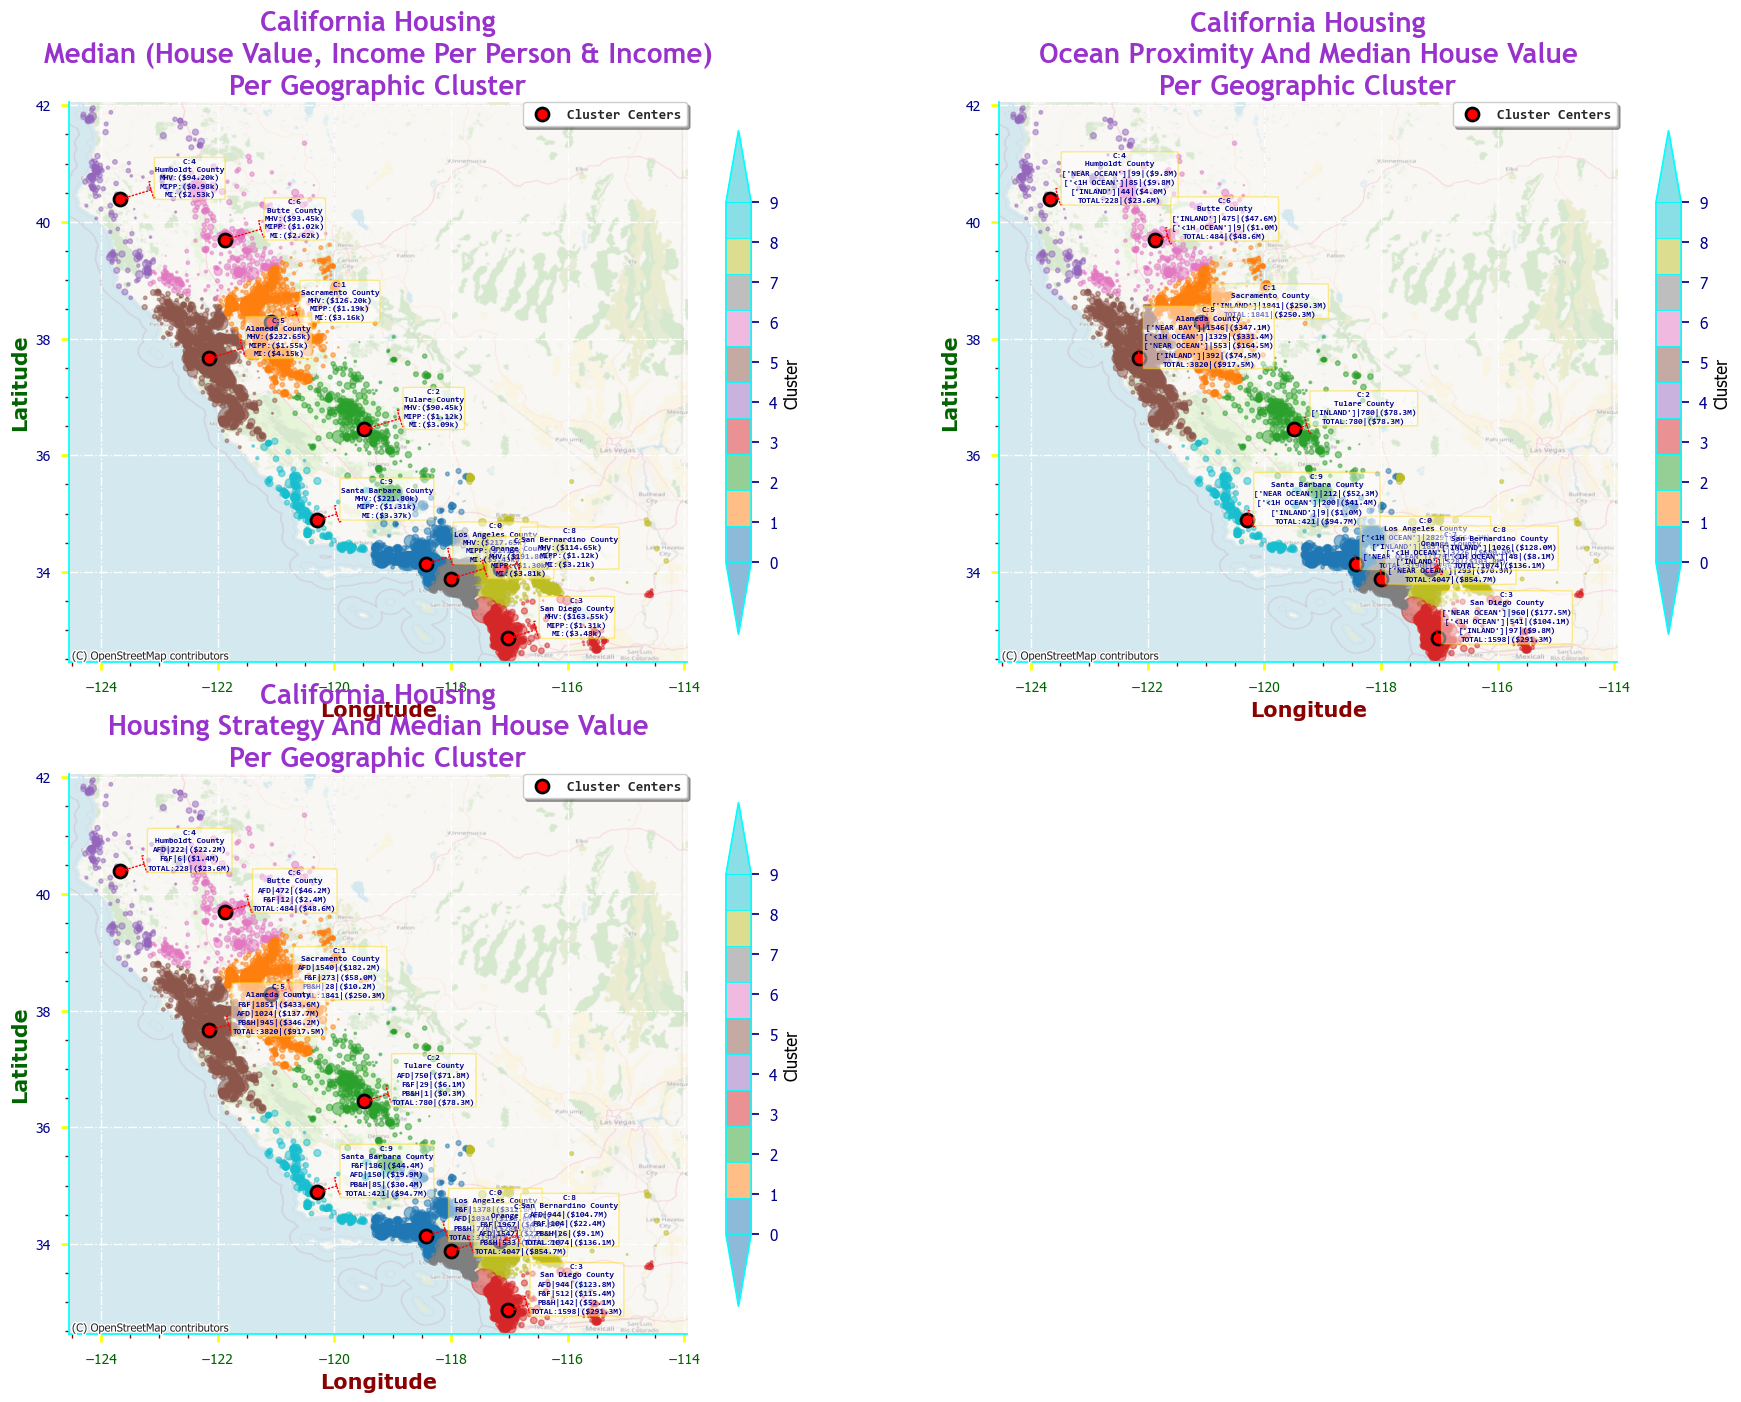

In [249]:
# ── Shared Setup ──────────────────────────────────────────────────────────────

# Fit KMeans on location
kmeans = KMeans(n_clusters=10, random_state=42)
final["Cluster"] = kmeans.fit_predict(final[["latitude", "longitude"]])
median_house_value = final.groupby("Cluster")["median_house_value"].median()
income_per_person  = final.groupby("Cluster")["income_per_person"].median()
median_income      = final.groupby("Cluster")["median_income"].median()

# Shortened strategy names
strategy_short = {
    'Premium Buy & Hold'           : 'PB&H',
    'Volume Investment (Fix & Flip)': 'F&F',
    'Affordable Development'       : 'AFD'
}
final['Best Strategy Short'] = final['Best Strategy'].map(strategy_short)

# Best strategy annotation
best_strategy = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{strategy_short[k]}|{v}|(${x[x['Best Strategy']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['Best Strategy'].value_counts().items()])
        + f"\nTOTAL:{x['Best Strategy'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)")

# Ocean proximity annotation
ocean_proximity = final.groupby("Cluster").apply(
    lambda x: '\n'.join([
        f"{[k]}|{v}|(${x[x['ocean_proximity']==k]['median_house_value'].sum()/1e6:,.1f}M)" 
        for k, v in x['ocean_proximity'].value_counts().items()])
        + f"\nTOTAL:{x['ocean_proximity'].value_counts().sum()}|(${x['median_house_value'].sum()/1e6:,.1f}M)")

#==============================================================#

# # OLD BUILD - DO NOT USE!!
# # Import Geolocator
# from geopy.geocoders import Nominatim

# # Initialise Geolocator
# geolocator = Nominatim(user_agent="vym1")

# # Define get_location_name function
# def get_location_name(lat, lon):
#     location = geolocator.reverse(f"{lat}, {lon}")
#     return location.raw['address'].get('city') or \
#            location.raw['address'].get('town') or \
#            location.raw['address'].get('county')

# # Hardcode location names
# location_names = {
#     0: "Los Angeles",    1: "Newark",
#     2: "Ventura County", 3: "Fresno",
#     4: "Sacramento County", 5: "Santee",
#     6: "Trinity County", 7: "Sonoma County",
#     8: "Chino",          9: "Arroyo Grande"
# }
# def get_location_name(lat, lon):
#     return location_names.get(i, f"({lat:.1f}, {lon:.1f})")

#==============================================================#

from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="vym1")

def get_location_name(lat, lon):
    try:
        time.sleep(1)  # ✅ Respect Nominatim rate limit (1 req/sec)
        location = geolocator.reverse(
            f"{lat}, {lon}",
            exactly_one=True,
            language="en",
            zoom=8  # ✅ Key fix: zoom=8 = county/region level, not street level
        )
        if location is None:
            return f"({lat:.1f}, {lon:.1f})"
        
        address = location.raw['address']
        
        # ✅ Walk through from most to least specific regional name
        return (
            address.get('city')        or  # e.g. Los Angeles
            address.get('town')        or  # e.g. smaller towns
            address.get('village')     or  # e.g. rural areas
            address.get('suburb')      or  # e.g. city districts
            address.get('county')      or  # e.g. Trinity County
            address.get('state_district') or
            address.get('state')       or  # fallback to state
            f"({lat:.1f}, {lon:.1f})"     # final fallback
        )
    except Exception as e:
        print(f"Geocoding failed for ({lat}, {lon}): {e}")
        return f"({lat:.1f}, {lon:.1f})"

#==#

# Annotation styles
arrow = dict(arrowstyle="]->", color='red', mutation_aspect=1, linewidth=1,
             linestyle='dotted', capstyle='round', joinstyle='round',
             alpha=1, connectionstyle='arc3, rad=0')
box   = dict(boxstyle="round4", pad=0.1, facecolor='white', alpha=0.45, edgecolor='gold')

# Colorbar settings
fmt      = lambda x, pos: '{:,.0f}'.format(x)
cbar_kws = {"orientation":"vertical", "shrink":0.9, 'extend':'both',
            'extendfrac':0.2, "drawedges":True, 'label':'Cluster',
            'spacing':'uniform', 'format':fmt}

# Legend/title font props
title_props  = dict(family='consolas', style='normal', weight='bold', size='small')
legend_props = dict(family='consolas', style='normal', weight='bold', size='small')

# ── Subplot Figure ─────────────────────────────────────────────────────────────

fig, ((gc1, gc2), (gc3, gc4)) = plt.subplots(
    ncols=2, nrows=2,
    figsize=(22, 16),
    facecolor='white',
    dpi=100
)

# ── Helper: shared scatter setup ───────────────────────────────────────────────

def base_scatter(ax):
    scatter = ax.scatter(
        final["longitude"], final["latitude"],
        c=final["Cluster"], cmap="tab10",
        s=final["population"] / 100, alpha=0.5
    )
    ax.scatter(
        kmeans.cluster_centers_[:, 1],
        kmeans.cluster_centers_[:, 0],
        c="red", ec='black', marker=".", s=350,
        linewidths=2, label="Cluster Centers"
    )
    return scatter

def base_format(ax, scatter, title):
    plt.colorbar(scatter, ax=ax, **cbar_kws)
    legend = ax.legend(
        loc='best', bbox_to_anchor=(1, 1), borderaxespad=0,
        title='', title_fontproperties=title_props,
        prop=legend_props, frameon=True, shadow=True, fancybox=True
    )
    legend.get_title().set_color("darkred")
    ax.set_title(title, loc='center', fontdict=title_font)
    ax.set_xlabel('Longitude', loc='center', fontdict=x_label_font)
    ax.set_ylabel('Latitude',  loc='center', fontdict=y_label_font)
    ax.tick_params(axis='x', labelrotation=None)
    ax.tick_params(axis='y', labelrotation=None)
    ax.minorticks_on()
    ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    ctx.add_basemap(ax, crs="EPSG:4326",
                    source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)
    ax.set_xlim(-124.55, -113.95)
    ax.set_ylim(32.45,   42.05)

# ── GC1 — MHV, Income & Income Per Person ─────────────────────────────────────

scatter = base_scatter(gc1)
for i, center in enumerate(kmeans.cluster_centers_):
    location_name = get_location_name(center[0], center[1])
    gc1.annotate(
        f"C:{i}\n{location_name}\nMHV:(${median_house_value[i]/1000:,.2f}k)"
        f"\nMIPP:(${income_per_person[i]/1000:,.2f}k)\nMI:(${median_income[i]/1000:,.2f}k)",
        xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points",
        ha='center', va='center', color='darkblue', fontsize=6, fontweight="bold",
        fontfamily='consolas', arrowprops=arrow, bbox=box
    )
base_format(gc1, scatter,
    'California Housing\nMedian (House Value, Income Per Person & Income)\nPer Geographic Cluster')

# ── GC2 — Ocean Proximity ─────────────────────────────────────────────────────

scatter = base_scatter(gc2)
for i, center in enumerate(kmeans.cluster_centers_):
    location_name = get_location_name(center[0], center[1])
    gc2.annotate(
        f"C:{i}\n{location_name}\n{ocean_proximity[i]}",
        xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points",
        ha='center', va='center', color='darkblue', fontsize=6, fontweight="bold",
        fontfamily='consolas', arrowprops=arrow, bbox=box
    )
base_format(gc2, scatter,
    'California Housing\nOcean Proximity And Median House Value\nPer Geographic Cluster')

# ── GC3 — Best Strategy ───────────────────────────────────────────────────────

scatter = base_scatter(gc3)
for i, center in enumerate(kmeans.cluster_centers_):
    location_name = get_location_name(center[0], center[1])
    gc3.annotate(
        f"C:{i}\n{location_name}\n{best_strategy[i]}",
        xy=(center[1], center[0]), xytext=(50, 15), textcoords="offset points",
        ha='center', va='center', color='darkblue', fontsize=6, fontweight="bold",
        fontfamily='consolas', arrowprops=arrow, bbox=box
    )
base_format(gc3, scatter,
    'California Housing\nHousing Strategy And Median House Value\nPer Geographic Cluster')

# ── GC4 — Placeholder (share your 4th plot) ───────────────────────────────────

gc4.set_visible(False)  # Hidden until you share gc4 code

# ── Save & Show ───────────────────────────────────────────────────────────────

# my_path = r"\Users\tailb\Downloads"
# plt.tight_layout()
# plt.savefig(my_path + '/Map_Combined.png',
#             bbox_inches='tight', pad_inches=0.1,
#             facecolor='auto', edgecolor='yellow', dpi='figure')

# # ── Save plot as png ───────────────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_MHV_MIPP_MI_OP_And_HS_Per_Geographic_Cluster_Geospatial_KMeans_Cluster_Bubble_Map.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# ── Display plot ───────────────────────────────────────────────────────────────
plt.show()

##### `🏡 California Housing: Cluster And Location Name Median House Value Statistics`.

**`Cluster And Location Name Median House Value Statistics - 1`**.

In [250]:
ln1 = final.groupby(['Cluster', 'location_name'])['median_house_value'].agg(['count', 'mean', 'median', 'sum']).sort_values(by='count', ascending=False).round(2).reset_index()\
    .assign(proportion=lambda x: x["count"] / x["count"].sum())
ln1['count_rank'] = ln1['count'].rank(ascending=False)
ln1['median_rank'] = ln1['median'].rank(ascending=False) 
ln1['sum_rank'] = ln1['sum'].rank(ascending=False)
ln1

#==#

# # Styled - Not for plotting!!
# ln1 = final.groupby(['Cluster', 'location_name'])['median_house_value'].agg(['count', 'mean',  'median', 'sum']).sort_values(by='sum', ascending=False).reset_index()\
#     .assign(proportion=lambda x: x["sum"] / x["sum"].sum()).style.format({'count':'{:,.0f}', 'mean':'${:,.0f}', 'median':'${:,.0f}', 'sum':'${:,.0f} M', 'proportion':'{:.2%}'})
# ln1

#==#

# ln1 = (final['location_name'].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())
# )
# ln1

# # Styled - Not for plotting!!
# ln1 = (final['location_name'].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())\
# .style.format({"count": "{:,.0f}","proportion": "{:.2%}"})
# )
# ln1

,Cluster,location_name,count,mean,median,sum,proportion,count_rank,median_rank,sum_rank
0,7,Orange County,4047,211185.89,191800.0,854669300.0,0.231482,1.0,4.0,2.0
1,5,Alameda County,3820,240170.55,232650.0,917451500.0,0.218498,2.0,1.0,1.0
2,0,Los Angeles County,3190,230736.93,217650.0,736050800.0,0.182463,3.0,3.0,3.0
3,1,Sacramento County,1841,135966.59,126200.0,250314500.0,0.105302,4.0,6.0,5.0
4,3,San Diego County,1598,182311.64,163550.0,291334000.0,0.091403,5.0,5.0,4.0
5,8,San Bernardino County,1074,126736.69,114650.0,136115200.0,0.061431,6.0,7.0,6.0
6,2,Tulare County,780,100348.72,90450.0,78272000.0,0.044615,7.0,10.0,8.0
7,6,Butte County,484,100459.71,93450.0,48622500.0,0.027684,8.0,9.0,9.0
8,9,Santa Barbara County,421,224864.37,221800.0,94667900.0,0.024081,9.0,2.0,7.0
9,4,Humboldt County,228,103462.28,94200.0,23589400.0,0.013041,10.0,8.0,10.0


**`Barplot 1  - Cluster And Location Name Median House Value Statistics`**.

'Orange County' - 1st, 4,047, 854,669,300, 23.15%
'Alameda County' - 2nd, 3,820, 917,451,500, 21.85%
'Los Angeles County' - 3rd, 3,190, 736,050,800, 18.25%


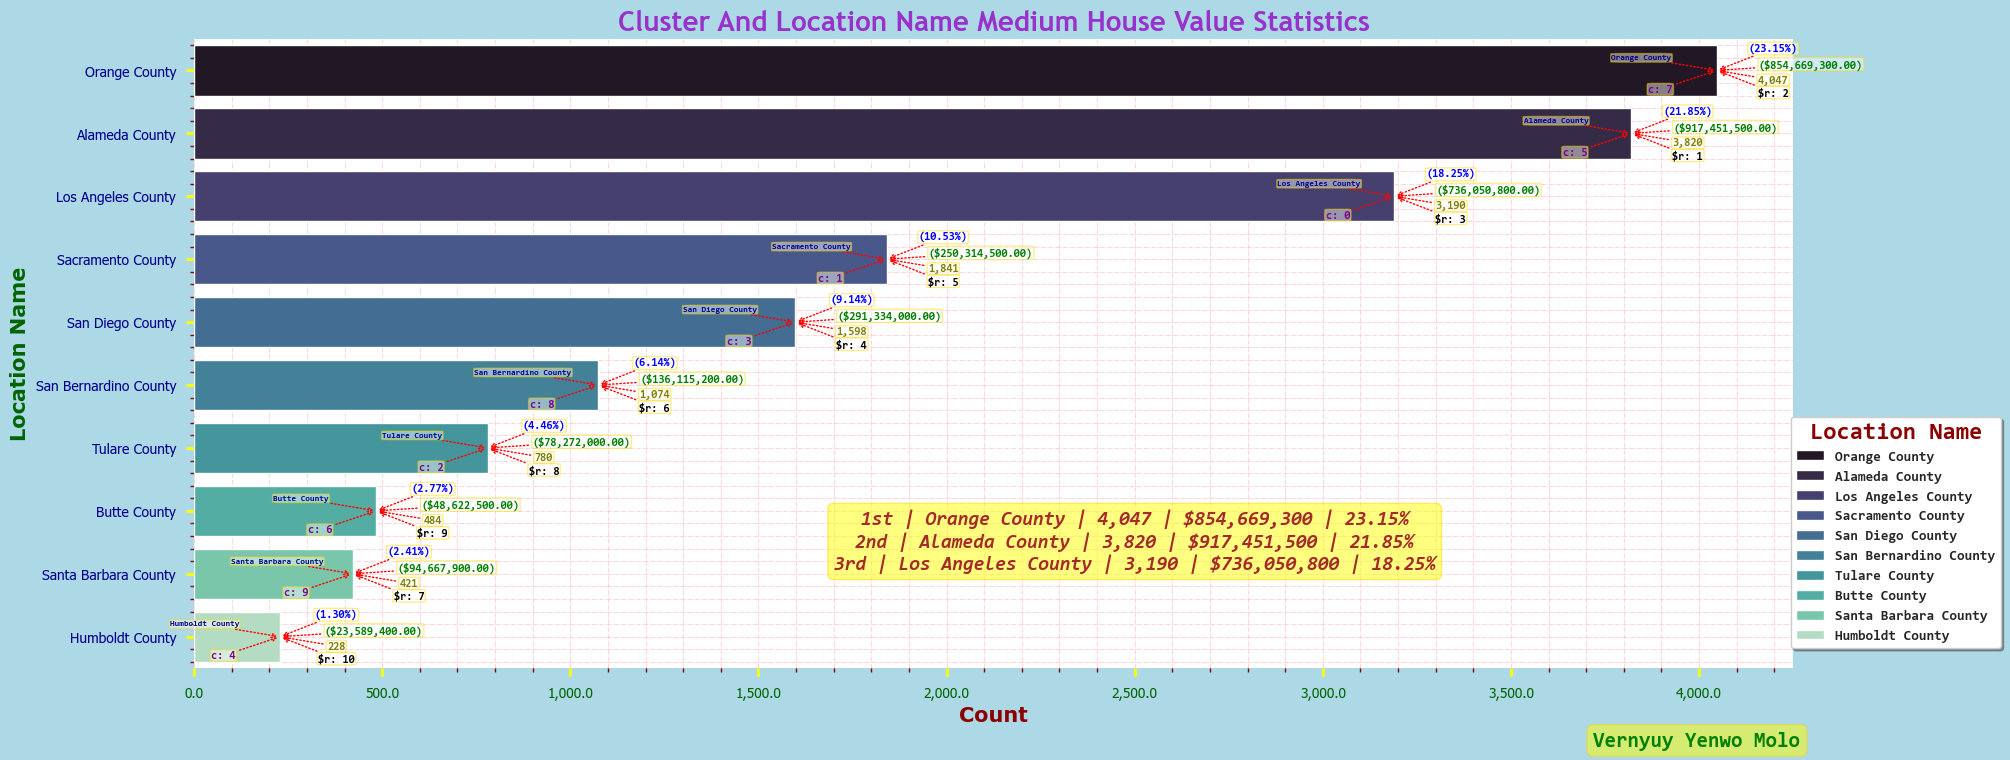

In [251]:
# Barplot 1 - Cluster And Location Name Medium House Value Statistics.

# Step 1: Prepare plot
fig, ln1_bplot = plt.subplots(ncols=1,nrows=1,figsize=(5,5),layout='constrained',facecolor='lightblue',dpi=100)

#==#

# Step 2: Plot 'count  ' vs 'category'
sns.barplot(data=ln1,x=ln1['count'],y=ln1['location_name'],
hue=ln1['location_name'],order=ln1['location_name'],hue_order=ln1['location_name'], 
estimator='mean',errorbar=('ci', 95),n_boot=1000,seed=None,units=None,weights=None,orient=None,color=None, 
palette='mako',saturation=0.75,fill=True,hue_norm=None,width=0.8,dodge=None,gap=0,log_scale=None,native_scale=False, 
formatter=None,legend='full',capsize=0,err_kws=None,ci='deprecated',errcolor=None,ax=ln1_bplot) # palette: mako, viridis, rocket, plasma, inferno, flare_r, cubehelix display big data with more visual variety

#==#

# Step 3: Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
ln1_bplot.figure.set_size_inches(20,7.5)
ln1_bplot.set_title('Cluster And Location Name Medium House Value Statistics',loc='center',fontdict=title_font)
ln1_bplot.set_xlabel('Count',loc='center',fontdict=x_label_font)
ln1_bplot.set_ylabel('Location Name',loc='center',fontdict=y_label_font)
ln1_bplot.xaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
# ln1_bplot.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))

ln1_bplot.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
ln1_bplot.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
ln1_bplot.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
ln1_bplot.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

ln1_bplot.minorticks_on()

ln1_bplot.spines[['top','right']].set_visible(False)
ln1_bplot.spines[['bottom','left']].set_visible(False)

ln1_bplot.set_facecolor('white')

ln1_bplot.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)

# ln1_bplot.autoscale()
# ln1_bplot.axis('equal')
# ln1_bplot.set_xlim(left=0)
# ln1_bplot.set_ylim(bottom=0)
# ln1_bplot.set_ylim(0,355000)
# ln1_bplot.set_xscale('log')
# ln1_bplot.set_yscale('log')
# ln1_bplot.set_yscale('linear')  # Try removing log scale

title_props=dict(family='consolas',style='normal',weight='bold',size='x-large')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = ln1_bplot.legend(loc='best',bbox_to_anchor=(1.13, 0.4),borderaxespad=0,title='Location Name',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

#==#

# Step 4: Annotate category, count, sum, sum_rank and proportion in arrow & bbox circle format - Category, Count #, Sum $, Sum Rank & Proportion %

# Annotation format properties
arrow = dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
box=dict(boxstyle="round4",pad=0.1,facecolor='white',alpha=0.45,edgecolor='gold')

# Unique item categories
items = ln1['location_name'].unique().tolist()

# Annotate Cluster in arrow & bbox circle format - Cluster
for index, row in ln1.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['Cluster']): # Only annotate if Cluster is not NaN
        item = row['location_name'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            ln1_bplot.annotate(text=f'c: {row['Cluster']:,.0f}', 
            xy=(row['count'], y_coord), xytext=(row['count'] - 150 , y_coord + 0.30), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='purple' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate sum_rank in arrow & bbox circle format - $ Sum Rank
for index, row in ln1.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['sum_rank']): # Only annotate if sum_rank is not NaN
        item = row['location_name'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            ln1_bplot.annotate(text=f'$r: {row['sum_rank']:,.0f}', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 150 , y_coord + 0.35), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='black' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate location_name in arrow & bbox circle format - Category
for index, row in ln1.iloc[:].iterrows(): # Use [:-1] to skip last row if needed
    item = row['location_name'] # Extract item name
    if item in items:
        y_coord = items.index(item) # map item to y coordinate
        ln1_bplot.annotate(text=f"{item}",
        xy=(row['count'], y_coord), xytext=(row['count'] - 200, y_coord - 0.20), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
        color='darkblue',
        ha='center', va='center', family='consolas', fontstyle='normal',
        fontsize=6, fontweight='bold', rotation=0, 
        bbox=box, arrowprops=arrow) 

# Annotate count in arrow & bbox circle format - Count
for index, row in ln1.iloc[:].iterrows(): # Use [:-1] to exclude last row if needed
    if not pd.isna(row['count']): # Only annotate if count is not NaN
        item = row['location_name'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            ln1_bplot.annotate(text=f'{row['count']:,.0f}', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 150 , y_coord + 0.15), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='olive' if row['count'] >= 0 else 'red',
            ha='center', va='center',
            family='consolas', fontstyle='normal',
            fontsize=8, fontweight='bold', rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate sum in arrow & bbox circle format - $ Sum
for index, row in ln1.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['sum']): # Only annotate if sum is not NaN
        item = row['location_name'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            ln1_bplot.annotate(text=f'(${row['sum']:,.2f})', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 250 , y_coord - 0.10), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='green' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate proportion in arrow & bbox circle format - %
for index, row in ln1.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['proportion']): # Only annotate if proportion is not NaN
        item = row['location_name'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            ln1_bplot.annotate(text=f'({row['proportion']:,.2%})', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 150 , y_coord - 0.35), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='blue' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

#==#

# Step 6: Add signature to figure in bbox round format
ln1_bplot.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ln1_bplot.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

#==#

# Step 7: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean_1 = ln1.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by count in descending order and select top 3
top_counts_1 = df_clean_1.sort_values(by='count', ascending=False).head(3)

# Display the top 3 highest counts
for i, row in top_counts_1.iterrows():
    rank = ['1st', '2nd', '3rd'][top_counts_1.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['count']:,.0f}, {row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_counts_1.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
ln1_bplot.annotate(annotation_text,xy=(2500, 8),xytext=(2500, 8),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))  

#==#

# # Step 8: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Cluster_And_Location_Name_Median_House_Value_Statistics_1_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Step 9: Display plot
plt.show()

**`Cluster And Location Name Median House Value Statistics - 2`**.

In [252]:
ln2 = final.groupby(['Cluster', 'location_name'])['median_house_value'].agg(['count', 'mean', 'median', 'sum']).sort_values(by='sum', ascending=False).round(2).reset_index()\
    .assign(proportion=lambda x: x["sum"] / x["sum"].sum())
ln2['count_rank'] = ln2['count'].rank(ascending=False)
ln2['median_rank'] = ln2['median'].rank(ascending=False) 
ln2['sum_rank'] = ln2['sum'].rank(ascending=False)
ln2

#==#

# # Styled - Not for plotting!!
# ln2 = final.groupby(['Cluster', 'location_name', 'Best Strategy Short'])['median_house_value'].agg(['count', 'mean', 'median', 'sum']).sort_values(by='sum', ascending=False).reset_index()\
#     .assign(proportion=lambda x: x["sum"] / x["sum"].sum()).style.format({'count':'{:,.0f}', 'mean':'${:,.0f}', 'median':'${:,.0f}', 'sum':'${:,.0f} M', 'proportion':'{:.2%}'})
# ln2

# ln2 = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())
# )
# ln2

# # Styled - Not for plotting!!
# ln2 = (final["location_name"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())\
# .style.format({"count": "{:,.0f}","proportion": "{:.2%}"})
# )
# ln2


,Cluster,location_name,count,mean,median,sum,proportion,count_rank,median_rank,sum_rank
0,5,Alameda County,3820,240170.55,232650.0,917451500.0,0.267394,2.0,1.0,1.0
1,7,Orange County,4047,211185.89,191800.0,854669300.0,0.249096,1.0,4.0,2.0
2,0,Los Angeles County,3190,230736.93,217650.0,736050800.0,0.214524,3.0,3.0,3.0
3,3,San Diego County,1598,182311.64,163550.0,291334000.0,0.084910,5.0,5.0,4.0
4,1,Sacramento County,1841,135966.59,126200.0,250314500.0,0.072955,4.0,6.0,5.0
5,8,San Bernardino County,1074,126736.69,114650.0,136115200.0,0.039671,6.0,7.0,6.0
6,9,Santa Barbara County,421,224864.37,221800.0,94667900.0,0.027591,9.0,2.0,7.0
7,2,Tulare County,780,100348.72,90450.0,78272000.0,0.022813,7.0,10.0,8.0
8,6,Butte County,484,100459.71,93450.0,48622500.0,0.014171,8.0,9.0,9.0
9,4,Humboldt County,228,103462.28,94200.0,23589400.0,0.006875,10.0,8.0,10.0


**`Barplot 2  - Cluster And Location Name Median House Value Statistics`**.

'Alameda County' - 1st, 3,820, 917,451,500, 26.74%
'Orange County' - 2nd, 4,047, 854,669,300, 24.91%
'Los Angeles County' - 3rd, 3,190, 736,050,800, 21.45%


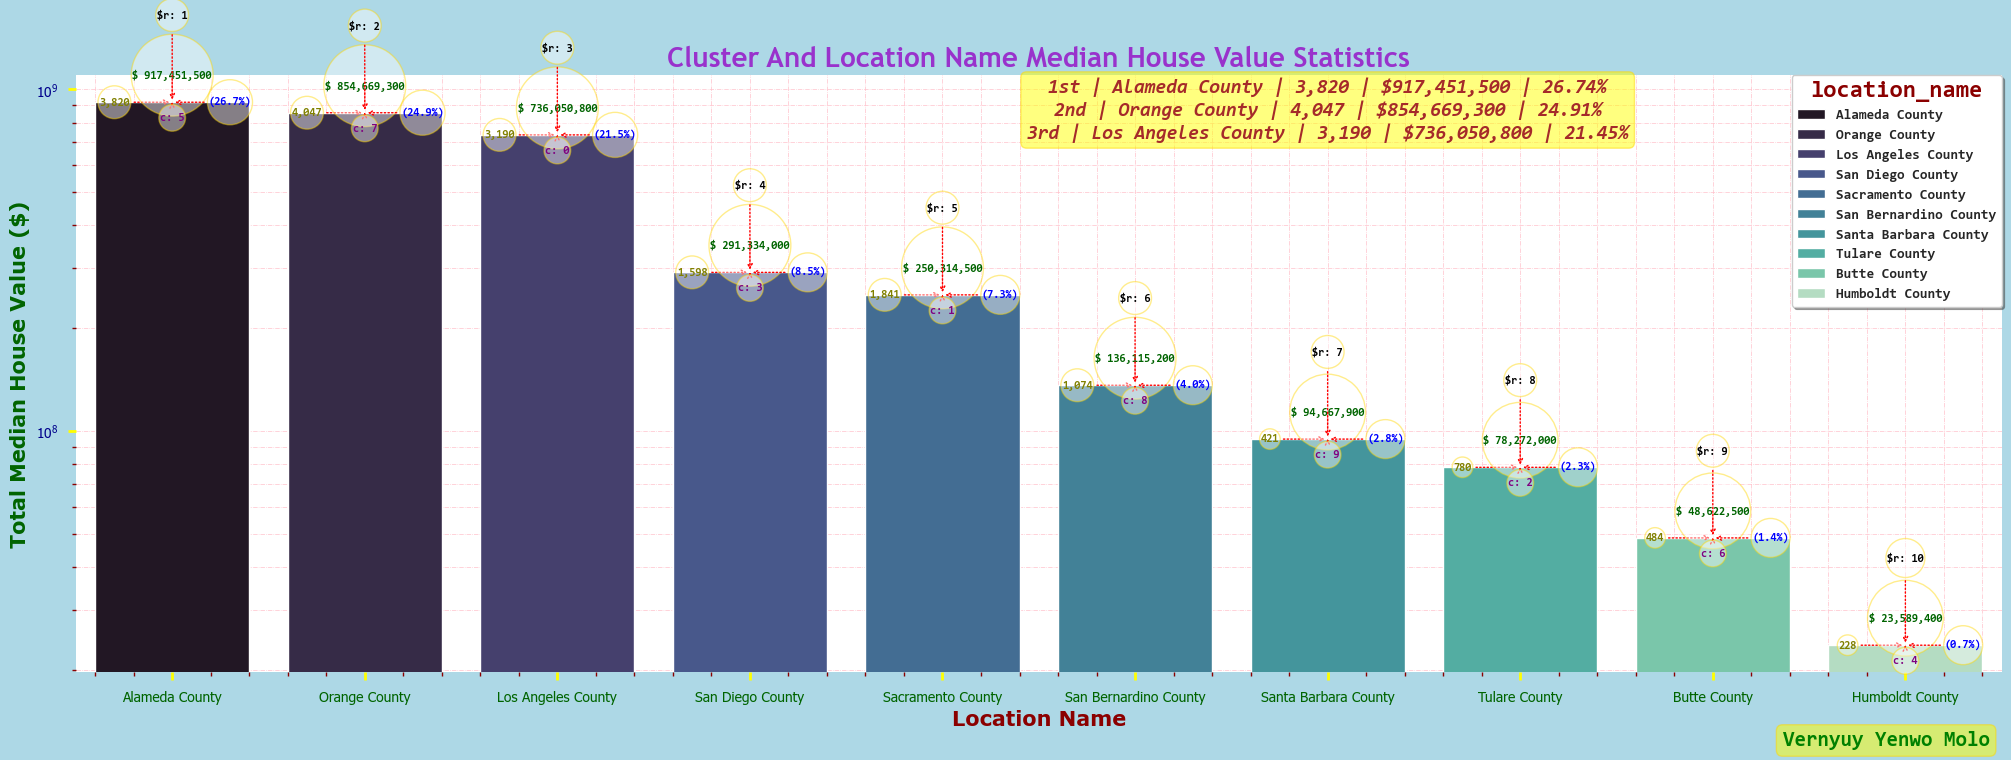

In [253]:
# Barplot 2 - Cluster And Location Name Median House Value Statistics.

# Step 1: Prepare plot
fig, bplot2 = plt.subplots(ncols=1,nrows=1,figsize=(21,8),layout='constrained',facecolor='lightblue',dpi=100)

#==#

# Step 2: Exclude the 'location_name' row by label, not by position before plotting
ln2 = ln2.loc[ln2['location_name'].notna()]

#==#

# Step 3: Plot 'location_name' vs 'sum'
sns.barplot(data=ln2,x=ln2['location_name'],y=ln2['sum'],hue=ln2['location_name'],order=ln2['location_name'],hue_order=ln2['location_name'], 
estimator='mean',errorbar=('ci', 95),n_boot=1000,seed=None,units=None,weights=None,orient=None,color=None, 
palette='mako',saturation=0.75,fill=True,hue_norm=None,width=0.8,dodge=None,gap=0,log_scale=None,native_scale=False, 
formatter=None,legend='full',capsize=0,err_kws=None,ci='deprecated',errcolor=None,ax=bplot2) # palette: mako, viridis, rocket, plasma, inferno, flare_r, cubehelix display big data with more visual variety

#==#

# Step 4: Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
bplot2.figure.set_size_inches(20,7.5)
bplot2.set_title('Cluster And Location Name Median House Value Statistics',loc='center',fontdict=title_font)
bplot2.set_xlabel('Location Name',loc='center',fontdict=x_label_font)
bplot2.set_ylabel('Total Median House Value ($)',loc='center',fontdict=y_label_font)
bplot2.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))

bplot2.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
bplot2.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
bplot2.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
bplot2.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

bplot2.minorticks_on()

bplot2.spines[['top','right']].set_visible(False)
bplot2.spines[['bottom','left']].set_visible(False)

bplot2.set_facecolor('white')

bplot2.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)

# bplot2.autoscale()
# bplot2.axis('equal')
# bplot2.set_xlim(left=0)
# bplot2.set_ylim(bottom=0)
# bplot2.set_ylim(0,355000)
# bplot2.set_xscale('log')
bplot2.set_yscale('log')
# bplot2.set_yscale('linear')  # Try removing log scale

title_props=dict(family='consolas',style='normal',weight='bold',size='x-large')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = bplot2.legend(loc='best',bbox_to_anchor=(1, 1),borderaxespad=0,title='location_name',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

#==#

# Step 5: Annotate category, count, sum, sum_rank and proportion in arrow & bbox circle format - Category, Count #, Sum $, Sum Rank & Proportion %

# Annotation format properties
arrow = dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
box = dict(boxstyle="circle",pad=0.1,facecolor='white',alpha=0.45,edgecolor='gold')

# # Annotate location_name in arrow & bbox circle format - Category
# for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
#     bplot2.annotate(text=f'{row['location_name']}',
#         xy=(index, row['sum']), xytext=(index + 0.0, row['sum'] * 1.800), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
#         color='black',
#         ha='center', va='center', family='consolas', fontstyle='normal', 
#         fontsize=8, fontweight='bold', rotation=0,
#         bbox=box, arrowprops=arrow)
    
# Annotate count in arrow & bbox circle format - Count
for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['count']):  # Only annotate if count is not NaN
        bplot2.annotate(text=f'{row['count']:,.0f}',
            xy=(index, row['sum']), xytext=(index - 0.3, row['sum'] * 1.000), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
            color='olive' if row['count']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold', rotation=0,
            bbox=box, arrowprops=arrow)
        
# # Annotate median in arrow & bbox circle format - Median $
# for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
#     if not pd.isna(row['median']):  # Only annotate if median is not NaN
#         bplot2.annotate(text=f'$ {row['median']:,.0f}',
#             xy=(index, row['sum']), xytext=(index - 0.3, row['sum'] * 1.075), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
#             color='darkgreen' if row['median']>=0 else 'red',
#             ha='center', va='center', family='consolas', fontstyle='normal', 
#             fontsize=7, fontweight='bold', rotation=0,
#             bbox=box, arrowprops=arrow)

# Annotate sum in arrow & bbox circle format - Sum $
for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['sum']):  # Only annotate if sum is not NaN
        bplot2.annotate(text=f'$ {row['sum']:,.0f}',
            xy=(index, row['sum']), xytext=(index + 0.0, row['sum'] * 1.200), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
            color='darkgreen' if row['sum']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold', rotation=0,
            bbox=box, arrowprops=arrow)
    
# Annotate proportion in arrow & bbox circle format - Proportion %
for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['proportion']):  # Only annotate if proportion is not NaN
        bplot2.annotate(text=f'({row['proportion']:,.1%})',
            xy=(index, row['sum']), xytext=(index + 0.3, row['sum'] * 1.000), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
            color='blue' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

# # Annotate proportion in arrow & bbox circle format - Proportion %
# for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
#     if not pd.isna(row['proportion']):  # Only annotate if proportion is not NaN
#         bplot2.annotate(text=f'({row['proportion']:.1f}%)',
#             xy=(index, row['sum']), xytext=(index + 0.3, row['sum'] * 1.075), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
#             color='purple' if row['proportion']>=0 else 'red',
#             ha='center', va='center', family='consolas', fontstyle='normal', 
#             fontsize=8, fontweight='bold',rotation=0,
#             bbox=box, arrowprops=arrow)
                
# Annotate cluster in arrow & bbox circle format - Cluster
for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['Cluster']):  # Only annotate if Cluster is not NaN
        bplot2.annotate(text=f'c: {row['Cluster']:,.0f}',
            xy=(index, row['sum']), xytext=(index + 0.0, row['sum'] * 0.90), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
            color='purple' if row['Cluster']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate sum_rank in arrow & bbox circle format - $ Sum Rank
for index, row in ln2.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['sum_rank']):  # Only annotate if sum_rank is not NaN
        bplot2.annotate(text=f'$r: {row['sum_rank']:,.0f}',
            xy=(index, row['sum']), xytext=(index + 0.0, row['sum'] * 1.800), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
            color='black' if row['sum_rank']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=8, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

#==#

# # Step 5: Annotate category, count, sum, sum_rank and proportion in arrow & bbox circle format - Category, Count #, Sum $, Sum Rank & Proportion %
# for index, row in ln2.iloc[:].iterrows():
#     label = f"{row['location_name']}"
#     if pd.notna(row['count']):
#         label += f"\n{row['count']:,.0f}"
#     if pd.notna(row['median']):
#         label += f"\n$ {row['median']:,.0f}"
#     if pd.notna(row['sum']):
#         label += f"\n$ {row['sum']:,.0f}"
#     if pd.notna(row['proportion']):
#         label += f"\n({row['proportion']:,.1%})"
#     if pd.notna(row['proportion']):
#         label += f"\n({row['proportion']:.1f}%)"
#     if pd.notna(row['sum_rank']):
#         label += f"\n{row['sum_rank']:,.0f}"

#     bplot2.annotate(text=label,xy=(index, row['sum']),xytext=(index + 0.0, row['sum'] * 1.010), # (index + -0.0 for left, +0.0 for right),(row['sum'] * > 1 for up, < 1 for down)
#         ha='center', va='center', family='consolas', fontstyle='normal',
#         fontsize=11, fontweight='bold', color='black', rotation=0,
#         bbox=box, arrowprops=arrow)

#==#

# Step 6: Add signature to figure in bbox round format
bplot2.text(0.94, -0.13,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=bplot2.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

#==#

# Step 7: Annotate rank, category, count , sum & proportion of top sales in arrow & bbox round format - Rank, Category, Count #, Sum $ & Proportion %

# Remove rows where 'location_name', 'count', 'mean', 'median', 'sum' & 'proportion' is NaN
df_clean_2 = ln2.dropna(subset=['location_name', 'count', 'mean', 'median', 'sum', 'proportion'])

# Sort by count in descending order and select top 3
top_counts_2 = df_clean_2.sort_values(by='sum', ascending=False).head(3) # count

# Display the top 3 highest counts
for i, row in top_counts_2.iterrows():
    rank = ['1st', '2nd', '3rd'][top_counts_2.index.get_loc(i)]
    print(f"'{row['location_name']}' - {rank}, {row['count']:,.0f}, {row['sum']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['location_name']} | {row['count']:,.0f} | ${row['sum']:,.0f} | {row['proportion']:,.2%}" # select ranking label, category, count, sum & proportion
    for i, row in top_counts_2.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
bplot2.annotate(annotation_text,xy=(6, 700000000),xytext=(6, 700000000),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))

#==#

# # Step 8: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Unsupervised_Learning\Assets_SSH_Analysis"
# plt.savefig(my_path + '/Py_00_Cluster_And_Location_Name_Median_House_Value_Statistics_2_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Step 9: Display plot
plt.show()

**`🗺️ Key Insights`**:
- -- 
   - **`🏆 Tier 1 (Highest) — Alameda County (C5, \$917.5M | 26.7% | 3,820 count | 21.8%) — 1st by ($) value, 2nd by (#) count`**.

   - **`🥈 Tier 2 (High) — Orange County (C7, \$854.7M | 24.9% | 4,047 count | 23.1%) — 2nd by ($) value and 1st by (#) count`**.

   - **`🥉 Tier 3 (Mid-High) — Los Angeles County (C0, \$736.1M| 21.5% | 3,190 count | 18.2%) — 3rd by ($) value and 3rd by (#) count`**.

   - **`4️⃣ Tier 4 (Mid) — San Diego County (C3, \$291.3M | 8.5% | 1,598 count | 9.1%) and Sacramento County (C1, \$250.3M | 7.3% | 1,841 count | 10.5%)`**.

   - **`5️⃣ Tier 5 (Mid-Low) — San Bernardino County (C8, \$136.1M | 4.0% | 1,074 count | 6.1%) and Santa Barbara County (C9, \$94.7M | 2.8% | 421 count | 2.4%)`**.
   
   - **`6️⃣ Tier 6 (Lowest) — Tulare County (C2, \$78.3M | 2.3% | 780 count | 4.5%), Butte County (C6, \$48.6M | 1.4% | 484 count | 2.8%) and Humboldt County (C4, \$23.6M | 0.7% | 228 count | 1.3%)`**.
- --
**`🎯 General Pattern`**:

  - **`📈 Coastal areas`** = **`higher prices`**.

  - **`📉 Inland/Rural areas`** = **`lower prices`**.

  - **`This confirms that location is a strong predictor of house prices! 🏠`**.
- --

**`Steamlit Project`**

In [255]:
# import streamlit as st
# import pandas as pd
# import plotly.express as px

# # Define path to california housing market data analysis file
# file_path = os.path.expanduser("~/Python-Documents/os/CSV Files/California_Housing_Market_Data_Analysis_modified_3.csv")


# # Set page config
# st.set_page_config(page_title="My Dashboard", layout="wide")

# # Title
# st.title("📊 My Data Dashboard")

# # Load data
# @st.cache_data
# def load_data():
#     df = pd.read_csv(file_path)
#     return df

# df = load_data()

# # Sidebar for filters
# st.sidebar.header("Filters")
# selected_column = st.sidebar.selectbox("Select column:", df.columns)

# # Display metrics
# col1, col2, col3 = st.columns(3)
# col1.metric("Total Records", len(df))
# col2.metric("Unique Values", df[selected_column].nunique())

# # Display data
# st.dataframe(df)

# # Chart example
# fig = px.bar(df, x=df.columns[0], y=df.columns[1])
# st.plotly_chart(fig)